In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, json, re, signal
from collections import Counter

PROJECT = '/content/drive/MyDrive/text2sql'

shutil.copy(f'{PROJECT}/utils_v4.py', '/content/utils.py')
sys.path.insert(0, '/content')
from utils import *

if not os.path.exists('/content/spider_raw'):
    os.system(f'unzip -q "{PROJECT}/spider_data.zip" -d /content/spider_raw/')
if not os.path.exists('/content/cosql_dataset'):
    os.system(f'unzip -q "{PROJECT}/cosql_dataset.zip" -d /content/')

data        = load_all()
schema_dict = data['schema_dict']
dev_json    = data['dev_json']
print("✅ Ready")

Mounted at /content/drive
Loading all Text2SQL data...
✅ dev.json loaded — 1,034 examples
✅ Schemas loaded — 166 databases
✅ CoSQL loaded — train: 7,343  dev: 1,007

✅ All data loaded and ready
✅ Ready


In [2]:
!pip install transformers accelerate bitsandbytes \
             sentence-transformers faiss-cpu networkx \
             sqlparse --quiet
print("✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 146.7 MB/s eta 0:00:00
✅ Dependencies installed


In [3]:
import json

with open(f'{PROJECT}/comparison_full.json') as f:
    data = json.load(f)

def calc(arr):
    return sum(arr)/len(arr)*100 if arr else 0

zs = data['zeroshot']
rr = data['rag_repair']

print("Hardness      n      Zero-Shot    RAG+Repair")
print("─" * 50)
for h in ['easy', 'medium', 'hard', 'extra hard']:
    zs_vals = zs['by_hard'][h]
    rr_vals = rr['by_hard'][h]
    print(f"{h:<14} {len(zs_vals):<6} {calc(zs_vals):.1f}%        {calc(rr_vals):.1f}%")

Hardness      n      Zero-Shot    RAG+Repair
──────────────────────────────────────────────────
easy           333    88.0%        87.4%
medium         355    71.8%        76.6%
hard           187    54.0%        63.6%
extra hard     159    64.8%        55.3%


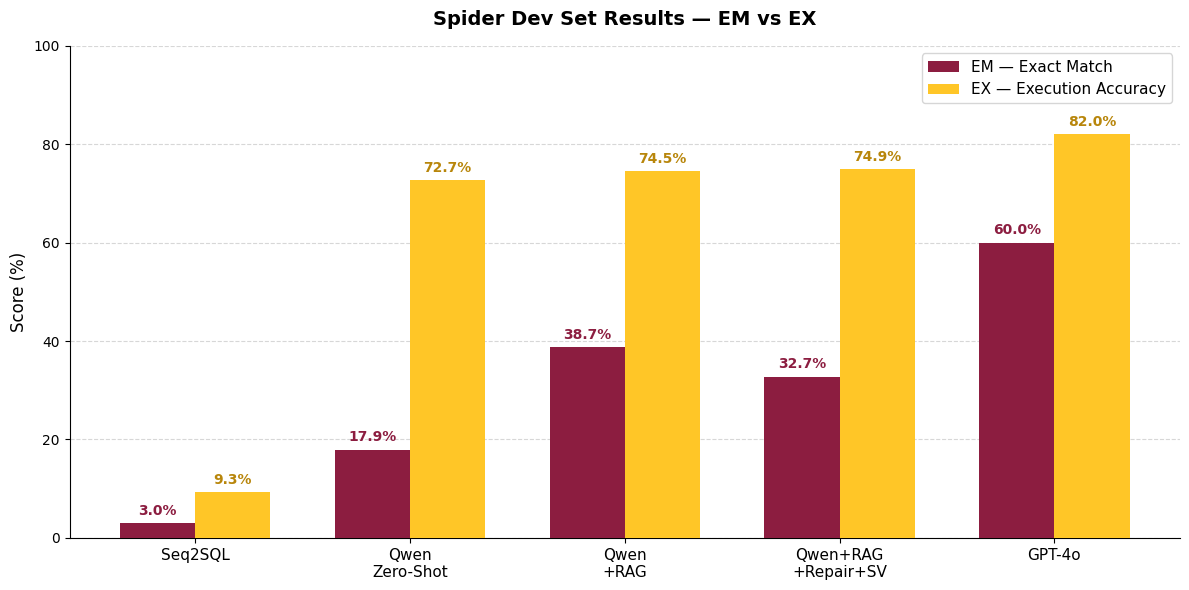

In [2]:
import matplotlib.pyplot as plt
import numpy as np

systems = ['Seq2SQL', 'Qwen\nZero-Shot', 'Qwen\n+RAG', 'Qwen+RAG\n+Repair+SV', 'GPT-4o']
em = [3.0, 17.9, 38.7, 32.7, 60.0]
ex = [9.3, 72.7, 74.5, 74.9, 82.0]

x = np.arange(len(systems))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, em, width, label='EM — Exact Match', color='#8C1D40', zorder=3)
bars2 = ax.bar(x + width/2, ex, width, label='EX — Execution Accuracy', color='#FFC627', zorder=3)

ax.bar_label(bars1, fmt='%.1f%%', padding=4, fontsize=10, color='#8C1D40', fontweight='bold')
ax.bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=10, color='#B8860B', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Spider Dev Set Results — EM vs EX', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('spider_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import pickle, networkx as nx

with open(f'{PROJECT}/all_graphs.pkl', 'rb') as f:
    all_graphs = pickle.load(f)
print(f"✅ Schema graphs loaded — {len(all_graphs)} databases")

faiss_data = load_faiss_indexes(PROJECT)
print("✅ FAISS indexes loaded")

✅ Schema graphs loaded — 166 databases


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ FAISS indexes loaded
   Questions : 8,659
   Schemas   : 166
✅ FAISS indexes loaded


Database    : concert_singer
Question    : Show the name and release year of the song by the youngest singer
All tables  : ['stadium', 'singer', 'concert', 'singer_in_concert']
Terminals   : ['singer', 'singer_in_concert']
FROM clause : FROM singer JOIN singer_in_concert ON singer_in_concert.singer_id = singer.singer_id



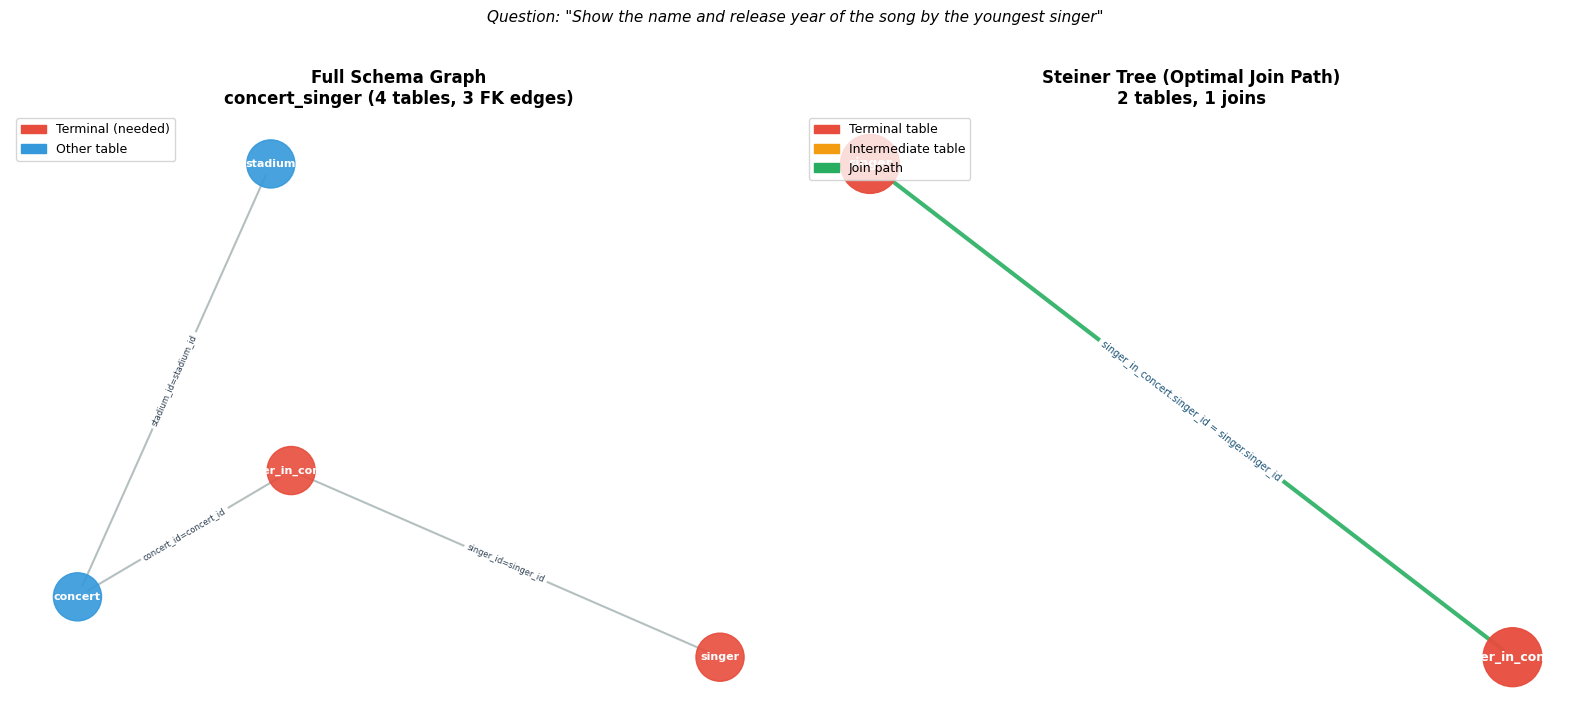

✅ Saved to /content/drive/MyDrive/text2sql/steiner_concert_singer.png
────────────────────────────────────────────────────────────
Database    : world_1
Question    : Which cities are in European countries where English is not official
All tables  : ['city', 'sqlite_sequence', 'country', 'countrylanguage']
Terminals   : ['city', 'sqlite_sequence', 'country']
FROM clause : FROM city JOIN country ON city.countrycode = country.code



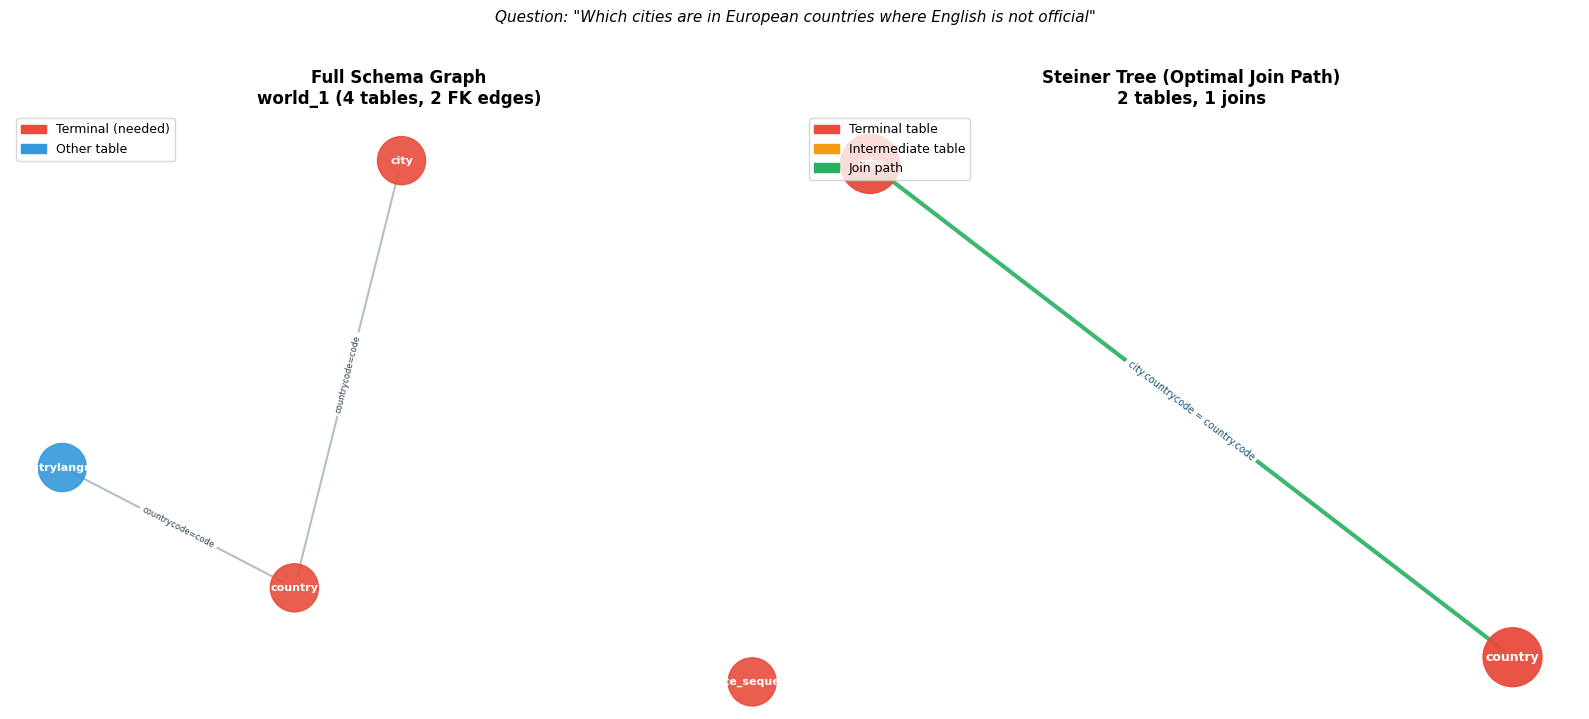

✅ Saved to /content/drive/MyDrive/text2sql/steiner_world_1.png
────────────────────────────────────────────────────────────
Database    : course_teach
Question    : List the names of teachers who have not been arranged to teach courses
All tables  : ['course', 'teacher', 'course_arrange']
Terminals   : ['course', 'teacher']
FROM clause : FROM course JOIN course_arrange ON course_arrange.course_id = course.course_id JOIN teacher ON course_arrange.teacher_id = teacher.teacher_id



KeyboardInterrupt: 

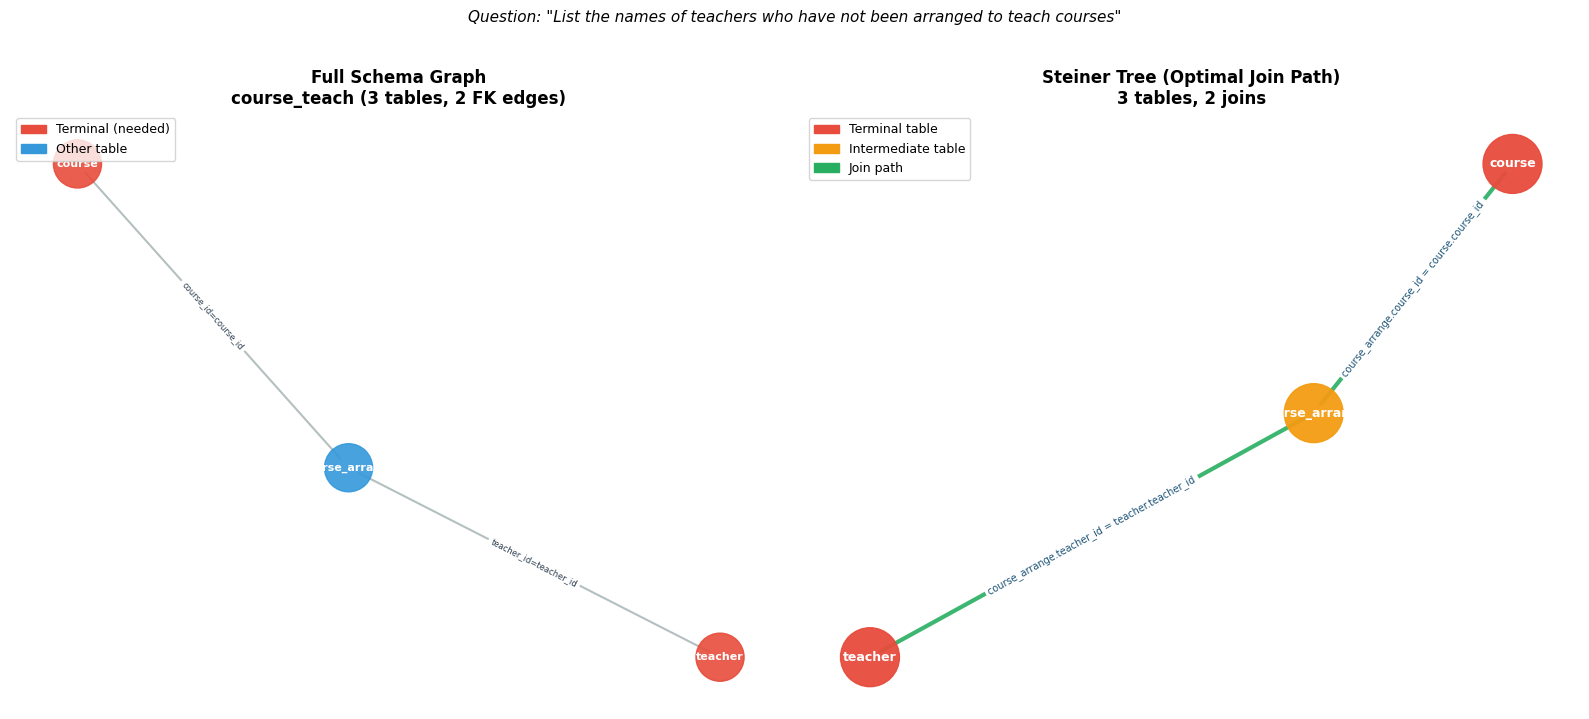

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualise_steiner(db_id, question, schema_dict, all_graphs):
    """
    Show the full schema graph and the Steiner tree
    for a given question side by side.
    """
    G = all_graphs.get(db_id)
    if G is None:
        print(f"No graph for {db_id}")
        return

    schema  = schema_dict.get(db_id, {})
    tables  = [t.lower() for t in schema.get('table_names_original', [])]

    # Get terminal tables from question keywords
    terminals = [t for t in tables
                 if t in question.lower() or
                 any(w in t for w in question.lower().split())]

    # Fallback — just use first 2-3 tables if no match
    if len(terminals) < 2:
        terminals = tables[:3]

    print(f"Database    : {db_id}")
    print(f"Question    : {question}")
    print(f"All tables  : {tables}")
    print(f"Terminals   : {terminals}")

    # Compute Steiner tree
    steiner = steiner_tree_approx(G, terminals)
    from_clause = build_from_clause(steiner)
    print(f"FROM clause : {from_clause}")
    print()

    # ── Plot ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Layout
    try:
        pos_full    = nx.spring_layout(G,       seed=42, k=2)
        pos_steiner = nx.spring_layout(steiner, seed=42, k=2)
    except:
        pos_full    = nx.circular_layout(G)
        pos_steiner = nx.circular_layout(steiner)

    # ── Left: Full Schema Graph ───────────────────────────────────
    ax1 = axes[0]
    ax1.set_title(f"Full Schema Graph\n{db_id} ({len(G.nodes)} tables, "
                  f"{len(G.edges)} FK edges)", fontsize=12, fontweight='bold')

    # Color nodes
    node_colors_full = []
    for node in G.nodes():
        if node in terminals:
            node_colors_full.append('#E74C3C')   # red = terminal
        else:
            node_colors_full.append('#3498DB')   # blue = other table

    nx.draw_networkx_nodes(G, pos_full, ax=ax1,
                           node_color=node_colors_full,
                           node_size=1200, alpha=0.9)
    nx.draw_networkx_labels(G, pos_full, ax=ax1,
                            font_size=8, font_color='white',
                            font_weight='bold')
    nx.draw_networkx_edges(G, pos_full, ax=ax1,
                           edge_color='#95A5A6', arrows=True,
                           arrowsize=15, width=1.5, alpha=0.7)

    # Edge labels — show join condition
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        cond = data.get('join_cond', '')
        if cond:
            # Shorten for readability
            parts = cond.split('=')
            if len(parts) == 2:
                left  = parts[0].strip().split('.')[-1]
                right = parts[1].strip().split('.')[-1]
                edge_labels[(u, v)] = f"{left}={right}"
    nx.draw_networkx_edge_labels(G, pos_full, edge_labels,
                                  ax=ax1, font_size=6,
                                  font_color='#2C3E50')

    # Legend
    red_patch  = mpatches.Patch(color='#E74C3C', label='Terminal (needed)')
    blue_patch = mpatches.Patch(color='#3498DB', label='Other table')
    ax1.legend(handles=[red_patch, blue_patch], loc='upper left', fontsize=9)
    ax1.axis('off')

    # ── Right: Steiner Tree ───────────────────────────────────────
    ax2 = axes[1]
    ax2.set_title(f"Steiner Tree (Optimal Join Path)\n"
                  f"{len(steiner.nodes)} tables, {len(steiner.edges)} joins",
                  fontsize=12, fontweight='bold')

    if steiner.number_of_nodes() > 0:
        node_colors_st = []
        for node in steiner.nodes():
            if node in terminals:
                node_colors_st.append('#E74C3C')   # red = terminal
            else:
                node_colors_st.append('#F39C12')   # orange = intermediate

        nx.draw_networkx_nodes(steiner, pos_steiner, ax=ax2,
                               node_color=node_colors_st,
                               node_size=1800, alpha=0.95)
        nx.draw_networkx_labels(steiner, pos_steiner, ax=ax2,
                                font_size=9, font_color='white',
                                font_weight='bold')
        nx.draw_networkx_edges(steiner, pos_steiner, ax=ax2,
                               edge_color='#27AE60', arrows=True,
                               arrowsize=20, width=3, alpha=0.9)

        # Show full join condition on edges
        st_edge_labels = {}
        for u, v, data in steiner.edges(data=True):
            cond = data.get('join_cond', '')
            st_edge_labels[(u, v)] = cond
        nx.draw_networkx_edge_labels(steiner, pos_steiner,
                                      st_edge_labels, ax=ax2,
                                      font_size=7, font_color='#1A5276')
    else:
        ax2.text(0.5, 0.5, 'No Steiner tree\n(terminals not connected)',
                 ha='center', va='center', transform=ax2.transAxes,
                 fontsize=12, color='red')

    # Legend
    red_p    = mpatches.Patch(color='#E74C3C', label='Terminal table')
    orange_p = mpatches.Patch(color='#F39C12', label='Intermediate table')
    green_p  = mpatches.Patch(color='#27AE60', label='Join path')
    ax2.legend(handles=[red_p, orange_p, green_p],
               loc='upper left', fontsize=9)
    ax2.axis('off')

    plt.suptitle(f'Question: "{question}"', fontsize=11,
                 style='italic', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{PROJECT}/steiner_{db_id}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved to {PROJECT}/steiner_{db_id}.png")


# ── Try it on a few examples ─────────────────────────────────────
examples_to_viz = [
    ("concert_singer",
     "Show the name and release year of the song by the youngest singer"),
    ("world_1",
     "Which cities are in European countries where English is not official"),
    ("course_teach",
     "List the names of teachers who have not been arranged to teach courses"),
]

for db_id, question in examples_to_viz:
    visualise_steiner(db_id, question, schema_dict, all_graphs)
    print("─" * 60)

In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-Coder-7B-Instruct"

print(f"Loading {MODEL_NAME}...")
print("(First time ~5 mins to download, after that ~1 min)")

quantization_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_compute_dtype    = torch.float16,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_use_double_quant = True,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config = quantization_config,
    device_map          = "auto",
    trust_remote_code   = True,
)
model.eval()

device = next(model.parameters()).device
print(f"✅ Qwen 7B loaded on {device}")
print(f"   GPU memory used: "
      f"{torch.cuda.memory_allocated()/1e9:.1f}GB / "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")

Loading Qwen/Qwen2.5-Coder-7B-Instruct...
(First time ~5 mins to download, after that ~1 min)


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Qwen 7B loaded on cuda:0
   GPU memory used: 5.7GB / 102.0GB


In [7]:
@torch.inference_mode()
def call_qwen(prompt: str,
              max_new_tokens: int = 512,
              temperature: float = 0.0) -> str:
    """
    Call HuggingFace Qwen model.
    temperature=0.0 for deterministic output.
    """
    messages = [
        {"role": "system", "content": "You are an expert Text-to-SQL assistant."},
        {"role": "user",   "content": prompt}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False if temperature == 0.0 else True,
            temperature    = temperature if temperature > 0 else None,
            pad_token_id   = tokenizer.eos_token_id,
        )

    # Decode only new tokens
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def call_qwen_for_pipeline(prompt: str, max_new_tokens: int = 300) -> str:
    """
    Wrapper that returns cleaned SQL.
    Used by the pipeline for SQL generation + repair steps.
    """
    raw = call_qwen(prompt, max_new_tokens=max_new_tokens, temperature=0.0)
    return extract_sql(raw)


def call_qwen_raw(prompt: str, max_new_tokens: int = 300) -> str:
    """
    Raw LLM call — returns text as-is, no SQL extraction.
    Used for back-translation and semantic check steps
    where we need English text, not SQL.
    """
    return call_qwen(prompt, max_new_tokens=max_new_tokens, temperature=0.0)

print("✅ LLM wrappers defined")

def extract_sql(raw_text: str) -> str:
    """Extract clean SQL from LLM response."""
    # Remove markdown code blocks
    raw_text = re.sub(r'```sql\s*', '', raw_text, flags=re.IGNORECASE)
    raw_text = re.sub(r'```\s*',    '', raw_text)

    lines = raw_text.strip().split('\n')
    sql_lines = []
    started = False
    for line in lines:
        stripped = line.strip()
        if not started:
            if stripped.upper().startswith('SELECT') or \
               stripped.upper().startswith('WITH'):
                started = True
                sql_lines.append(stripped)
        else:
            if stripped == '' and sql_lines:
                break
            sql_lines.append(stripped)

    if sql_lines:
        return ' '.join(sql_lines).rstrip(';').strip()
    return raw_text.strip().rstrip(';')


def parse_graph_json(raw_text: str) -> dict:
    """Extract and parse JSON from graph decomposition response."""
    raw_text = re.sub(r'```json\s*', '', raw_text, flags=re.IGNORECASE)
    raw_text = re.sub(r'```\s*',     '', raw_text)

    match = re.search(r'\{.*\}', raw_text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        text = match.group(0)
        text = re.sub(r',\s*}', '}', text)
        text = re.sub(r',\s*]', ']', text)
        try:
            return json.loads(text)
        except Exception:
            return None

print("✅ LLM call + helper functions defined")


✅ LLM wrappers defined
✅ LLM call + helper functions defined


✅ LLM wrappers defined


In [ ]:
# ── Run this cell ONCE then set RUN_ENRICHMENT = False ──────────
RUN_ENRICHMENT = False   # ← True on first run only

if RUN_ENRICHMENT:
    enrich_faiss_metadata(PROJECT, schema_dict,
                          f'{SPIDER_DIR}/train_spider.json')
    faiss_data = load_faiss_indexes(PROJECT)
    print("✅ Metadata enriched and FAISS reloaded")
else:
    print("ℹ️  Enrichment skipped — set RUN_ENRICHMENT=True on first run")

Enriching 8,659 examples with query graphs...
  [500/8659] done
  [1000/8659] done
  [1500/8659] done
  [2000/8659] done
  [2500/8659] done
  [3000/8659] done
  [3500/8659] done
  [4000/8659] done
  [4500/8659] done
  [5000/8659] done
  [5500/8659] done
  [6000/8659] done
  [6500/8659] done
  [7000/8659] done
  [7500/8659] done
  [8000/8659] done
  [8500/8659] done

✅ Metadata enriched and saved to /content/drive/MyDrive/text2sql/questions_metadata.pkl
   Backup saved to /content/drive/MyDrive/text2sql/questions_metadata_backup.pkl
   Query type distribution: {'unnested': 7309, 'nested_uncorrelated': 1346, 'nested_correlated': 4}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ FAISS indexes loaded
   Questions : 8,659
   Schemas   : 166
✅ Metadata enriched and FAISS reloaded


In [8]:
import signal

def timeout_handler(signum, frame):
    raise TimeoutError("SQL execution timeout")

def execute_sql_safe(db_id, sql, timeout=5):
    signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(timeout)
    try:
        result, err = execute_sql(db_id, sql)
        signal.alarm(0)
        return result, err
    except TimeoutError:
        return None, "Timeout"
    except Exception as e:
        signal.alarm(0)
        return None, str(e)


def level1_syntax_check(sql: str) -> tuple:
    """Level 1: basic syntax check."""
    try:
        import sqlparse
        parsed = sqlparse.parse(sql)
        if not parsed or not parsed[0].tokens:
            return False, "Empty or unparseable SQL"
        if not sql.strip().upper().startswith(('SELECT', 'WITH')):
            return False, "SQL does not start with SELECT or WITH"
        return True, ""
    except Exception as e:
        return False, str(e)


def validate_schema(sql: str, db_id: str, schema_dict: dict) -> tuple:
    """Level 2: check tables and columns exist in schema."""
    valid_cols   = get_valid_columns(db_id, schema_dict)
    valid_tables = set(valid_cols.keys())

    # Check tables
    for t1, t2 in re.findall(r'\bFROM\s+(\w+)|\bJOIN\s+(\w+)',
                               sql, re.IGNORECASE):
        t = (t1 or t2).lower()
        if t and t not in valid_tables:
            return False, f"Table '{t}' not in database '{db_id}'"

    # Check table.column references
    for table_alias, col in re.findall(r'\b(\w+)\.(\w+)\b', sql):
        if table_alias.upper() in ('SELECT','FROM','WHERE','GROUP',
                                    'ORDER','HAVING','LIMIT','ON'):
            continue
        t_lower = table_alias.lower()
        c_lower = col.lower()
        if t_lower in valid_cols:
            if c_lower not in valid_cols[t_lower] and c_lower != '*':
                return False, f"Column '{col}' not in table '{table_alias}'"

    return True, ""


def validate_and_repair(sql, question, db_id, schema_dict,
                         query_graph, steiner_from_clauses,
                         query_type, max_attempts=3):
    """3-level validation + targeted LLM repair loop."""
    schema_text = get_schema_text(db_id, schema_dict)
    repair_log  = []
    current_sql = sql

    for attempt in range(1, max_attempts + 1):

        # Level 1 — Syntax
        l1_ok, l1_err = level1_syntax_check(current_sql)
        if not l1_ok:
            repair_log.append({'attempt': attempt, 'level': 1, 'error': l1_err})
            if attempt < max_attempts:
                rp = build_repair_prompt(question, schema_text, current_sql,
                                         l1_err, query_graph,
                                         steiner_from_clauses, query_type, attempt)
                current_sql = extract_sql(call_qwen(rp, temperature=0.1))
            continue

        # Level 2 — Schema
        l2_ok, l2_err = validate_schema(current_sql, db_id, schema_dict)
        if not l2_ok:
            repair_log.append({'attempt': attempt, 'level': 2, 'error': l2_err})
            if attempt < max_attempts:
                rp = build_repair_prompt(question, schema_text, current_sql,
                                         l2_err, query_graph,
                                         steiner_from_clauses, query_type, attempt)
                current_sql = extract_sql(call_qwen(rp, temperature=0.1))
            continue

        # Level 3 — Execution
        exec_res, exec_err = execute_sql_safe(db_id, current_sql)
        if exec_err and exec_err != "Timeout":
            repair_log.append({'attempt': attempt, 'level': 3, 'error': exec_err})
            if attempt < max_attempts:
                rp = build_repair_prompt(question, schema_text, current_sql,
                                         exec_err, query_graph,
                                         steiner_from_clauses, query_type, attempt)
                current_sql = extract_sql(call_qwen(rp, temperature=0.1))
            continue

        # All passed
        return {
            'final_sql'   : current_sql,
            'passed_level': 3,
            'attempts'    : attempt,
            'repair_log'  : repair_log,
            'exec_result' : exec_res,
            'exec_error'  : None,
        }

    exec_res, exec_err = execute_sql_safe(db_id, current_sql)
    return {
        'final_sql'   : current_sql,
        'passed_level': None,
        'attempts'    : max_attempts,
        'repair_log'  : repair_log,
        'exec_result' : exec_res,
        'exec_error'  : exec_err,
    }

print("✅ Validation functions defined")

✅ Validation functions defined


In [9]:
def run_pipeline_v2(question: str, db_id: str, k_retrieve: int = 3) -> dict:
    """
    Pipeline v2:
    Call 1 → Graph decomposition (Qwen, schema-aware)
    Steiner → Schema-ground each node (pure Python)
    Call 2 → SQL generation (Qwen, graph + Steiner guided)
    Call 3 → Repair loop if fails (Qwen, targeted, max 3 attempts)
    """
    result = {
        'question'            : question,
        'db_id'               : db_id,
        'query_type'          : None,
        'graph_parsed'        : None,
        'steiner_from_clauses': None,
        'sql'                 : None,
        'exec_result'         : None,
        'exec_error'          : None,
        'stage_failed'        : None,
        'repair_attempts'     : 0,
    }

    try:
        schema_text = get_schema_text(db_id, schema_dict)

        # ── Stage 1: RAG Retrieval ────────────────────────────────
        examples = retrieve_similar_examples(
            question, db_id, faiss_data, k=k_retrieve
        )

        # ── Stage 2: Call 1 — Graph Decomposition ─────────────────
        decompose_prompt = build_decompose_prompt(
            question, schema_text, examples
        )
        graph_raw   = call_qwen(decompose_prompt, max_new_tokens=512)
        query_graph = parse_graph_json(graph_raw)

        # Fallback if graph parse fails
        if query_graph is None:
            query_graph = {
                "query_type": "unnested",
                "nodes": [{"id": 1, "scope": "outer",
                           "nlq_hint": question,
                           "tables_needed": [],
                           "operation": "SELECT",
                           "has_aggregation": False,
                           "has_group_by": False,
                           "has_order_by": False,
                           "filter_condition": "",
                           "depends_on": []}],
                "edges": []
            }
            result['stage_failed'] = 'graph_parse_failed_used_fallback'

        query_type              = query_graph.get("query_type", "unnested")
        result['graph_parsed']  = query_graph
        result['query_type']    = query_type

        # ── Stage 3: Steiner Tree per node ────────────────────────
        steiner_from_clauses = get_steiner_from_clauses(
            query_graph, db_id, all_graphs
        )

        # Fallback: if LLM left tables_needed empty, use first 2 tables
        for node in query_graph.get("nodes", []):
            nid = node["id"]
            if not steiner_from_clauses.get(nid):
                schema  = schema_dict.get(db_id, {})
                tables  = [t.lower() for t in
                           schema.get('table_names_original', [])]
                G = all_graphs.get(db_id)
                if G and tables:
                    steiner = steiner_tree_approx(G, tables[:2])
                    steiner_from_clauses[nid] = build_from_clause(steiner)

        result['steiner_from_clauses'] = steiner_from_clauses

        # ── Stage 4: Call 2 — SQL Generation ──────────────────────
        sql_prompt = build_sql_prompt(
            question, schema_text, query_graph,
            steiner_from_clauses, examples, query_type
        )
        sql_raw = call_qwen(sql_prompt, max_new_tokens=512)
        sql     = extract_sql(sql_raw)

        if not sql or len(sql) < 6:
            result['stage_failed'] = 'sql_generation_failed'
            return result

        result['sql'] = sql

        # ── Stage 5: Validation + Repair Loop ─────────────────────
        validation = validate_and_repair(
            sql, question, db_id, schema_dict,
            query_graph, steiner_from_clauses,
            query_type, max_attempts=3
        )

        result['sql']             = validation['final_sql']
        result['exec_result']     = validation['exec_result']
        result['exec_error']      = validation['exec_error']
        result['repair_attempts'] = validation['attempts'] - 1

        if validation['exec_error'] and validation['exec_error'] != "Timeout":
            if result['stage_failed'] is None:
                result['stage_failed'] = 'execution_failed'

    except Exception as e:
        result['stage_failed'] = f'pipeline_error: {str(e)}'

    return result

print("✅ Pipeline v2 defined")

✅ Pipeline v2 defined


In [ ]:
import random

# ── 20 random examples from dev (seed fixed for reproducibility) ─
random.seed(99)
smoke_indices = random.sample(range(len(dev_json)), 20)
smoke_examples = [dev_json[i] for i in smoke_indices]

# Show what we picked — difficulty distribution
smoke_dist = Counter(classify_hardness(ex['query']) for ex in smoke_examples)
smoke_subq = Counter(classify_subquery_type(ex['query']) for ex in smoke_examples)
print(f"Smoke test: 20 random examples from dev")
print(f"  Hardness  : {dict(smoke_dist)}")
print(f"  Subq type : {dict(smoke_subq)}")
print(f"  Indices   : {smoke_indices}")
print("=" * 60)

smoke_results = []
em_count = ex_count = 0

for i, ex in enumerate(smoke_examples):
    orig_idx = smoke_indices[i]
    print(f"\n[{i+1}/20] idx={orig_idx} | {ex['db_id']} | {classify_hardness(ex['query'])} | {classify_subquery_type(ex['query'])}")
    print(f"  Q    : {ex['question']}")
    print(f"  Gold : {ex['query']}")

    result = run_pipeline_v2(ex['question'], ex['db_id'])

    print(f"  Type : {result['query_type']}")
    print(f"  Graph: {'✅' if result['graph_parsed'] else '❌ fallback'}")
    print(f"  SQL  : {result['sql']}")
    print(f"  Fix  : {result['repair_attempts']} repair(s)")

    if result['stage_failed']:
        print(f"  ⚠️   : {result['stage_failed']}")
    if result['exec_error']:
        print(f"  ERR  : {result['exec_error']}")

    em = exact_match_normalized(result['sql'] or '', ex['query'])
    ex_match = execution_match(ex['db_id'], result['sql'] or '', ex['query'])
    em_count += em
    ex_count += ex_match

    print(f"  EM   : {'✅' if em else '❌'}  |  EX : {'✅' if ex_match else '❌'}")

    smoke_results.append({
        **result,
        'original_idx': orig_idx,
        'gold_sql'    : ex['query'],
        'hardness'    : classify_hardness(ex['query']),
        'subq_type'   : classify_subquery_type(ex['query']),
        'em'          : em,
        'ex'          : ex_match,
    })

print(f"\n{'='*60}")
print(f"SMOKE TEST SUMMARY  (20 random examples)")
print(f"{'='*60}")
print(f"  EM : {em_count}/20  ({em_count/20*100:.0f}%)")
print(f"  EX : {ex_count}/20  ({ex_count/20*100:.0f}%)")

# Breakdown by type
for subq in ['unnested','nested_uncorrelated','nested_correlated']:
    subset = [r for r in smoke_results if r['subq_type'] == subq]
    if subset:
        ex_s = sum(r['ex'] for r in subset)
        print(f"  EX {subq:<30}: {ex_s}/{len(subset)}")

print(f"  Repairs used : {sum(r['repair_attempts'] for r in smoke_results)}")
print(f"  Graph fails  : {sum(1 for r in smoke_results if not r['graph_parsed'])}")
print(f"{'='*60}")

Smoke test: 20 random examples from dev
  Hardness  : {'easy': 8, 'extra hard': 7, 'medium': 2, 'hard': 3}
  Subq type : {'unnested': 13, 'nested_uncorrelated': 7}
  Indices   : [827, 779, 409, 366, 471, 508, 272, 177, 514, 784, 183, 1002, 408, 863, 443, 765, 794, 435, 311, 945]

[1/20] idx=827 | orchestra | easy | unnested
  Q    : Return the names of conductors that do not have the nationality "USA".
  Gold : SELECT Name FROM conductor WHERE Nationality != 'USA'
  Type : unnested
  Graph: ✅
  SQL  : SELECT Name FROM conductor WHERE Nationality != 'USA'
  Fix  : 0 repair(s)
  EM   : ✅  |  EX : ✅

[2/20] idx=779 | world_1 | extra hard | nested_uncorrelated
  Q    : Return the country codes for countries that do not speak English.
  Gold : SELECT CountryCode FROM countrylanguage EXCEPT SELECT CountryCode FROM countrylanguage WHERE LANGUAGE  =  "English"
  Type : nested_uncorrelated
  Graph: ✅
  SQL  : SELECT Code FROM country WHERE Code NOT IN (SELECT CountryCode FROM countrylanguage WH

In [10]:
def run_no_rag(question: str, db_id: str) -> dict:
    schema_text = get_schema_text(db_id, schema_dict)

    prompt = f"""You are an expert Text-to-SQL system.

DATABASE SCHEMA:
{schema_text}

CRITICAL RULES:
- Only use tables and columns from the DATABASE SCHEMA above
- Return ONLY the SQL query — no explanation, no markdown, no backticks

QUESTION: {question}

SQL:"""

    raw = call_qwen(prompt, max_new_tokens=256)
    sql = extract_sql(raw)
    exec_res, exec_err = execute_sql_safe(db_id, sql)

    return {'question': question, 'db_id': db_id,
            'sql': sql, 'exec_error': exec_err}


# ── Run both on same 20 smoke examples ──────────────────────────
print("Pipeline v2  vs  No-RAG Baseline")
print("=" * 70)
print(f"{'#':<4} {'hardness':<12} {'subq_type':<25} {'v2':>5} {'NoRAG':>6} {'':}")
print("-" * 70)

no_rag_results = []
v2_ex = no_rag_ex = 0

for i, ex in enumerate(smoke_examples):
    no_rag = run_no_rag(ex['question'], ex['db_id'])

    gr, ge = execute_sql_safe(ex['db_id'], ex['query'])
    nr, ne = execute_sql_safe(ex['db_id'], no_rag['sql'])

    if ne == "Timeout" or ge == "Timeout": no_rag_match = False
    elif ne or ge:                          no_rag_match = False
    else:
        try:
            no_rag_match = sorted(str(x) for x in nr) == \
                           sorted(str(x) for x in gr)
        except:
            no_rag_match = False

    subq = classify_subquery_type(ex['query'])
    hard = classify_hardness(ex['query'])
    no_rag_results.append({**no_rag, 'ex': no_rag_match,
                            'subq_type': subq, 'hardness': hard})

    v2_match  = smoke_results[i]['ex']
    v2_ex    += v2_match
    no_rag_ex += no_rag_match

    flag = ''
    if v2_match and not no_rag_match: flag = '← v2 wins'
    if no_rag_match and not v2_match: flag = '← NoRAG wins'

    print(f"{i+1:<4} {hard:<12} {subq:<25} "
          f"{'✅' if v2_match else '❌':>5}  "
          f"{'✅' if no_rag_match else '❌':>5}  {flag}")

print("=" * 70)
print(f"{'TOTAL':<42} {v2_ex}/20    {no_rag_ex}/20")
print(f"{'EX accuracy':<42} {v2_ex/20*100:.0f}%      {no_rag_ex/20*100:.0f}%")

# ── Breakdown by subquery type ───────────────────────────────────
print(f"\nEX by subquery type:")
print(f"{'type':<30} {'v2':>8} {'NoRAG':>8}")
print("-" * 48)
for subq in ['unnested','nested_uncorrelated','nested_correlated']:
    v2_sub  = [r for r in smoke_results    if r['subq_type'] == subq]
    nr_sub  = [r for r in no_rag_results   if r['subq_type'] == subq]
    if not v2_sub: continue
    v2_s  = sum(r['ex'] for r in v2_sub)
    nr_s  = sum(r['ex'] for r in nr_sub)
    n     = len(v2_sub)
    print(f"{subq:<30} {v2_s}/{n} ({v2_s/n*100:.0f}%)  "
          f"{nr_s}/{n} ({nr_s/n*100:.0f}%)")

# ── Cases where they differ ──────────────────────────────────────
print(f"\nCases where pipelines disagree:")
for i, (v2r, nrr) in enumerate(zip(smoke_results, no_rag_results)):
    if v2r['ex'] != nrr['ex']:
        winner = "v2 wins" if v2r['ex'] else "NoRAG wins"
        print(f"\n  [{i+1}] {winner} | {nrr['subq_type']} | {nrr['hardness']}")
        print(f"  Q     : {smoke_examples[i]['question']}")
        print(f"  Gold  : {smoke_examples[i]['query']}")
        print(f"  v2    : {v2r['sql']}")
        print(f"  NoRAG : {nrr['sql']}")

Pipeline v2  vs  No-RAG Baseline
#    hardness     subq_type                    v2  NoRAG 
----------------------------------------------------------------------


NameError: name 'smoke_examples' is not defined

In [11]:
def validate_and_repair_no_graph(sql, question, db_id, schema_dict,
                                  max_attempts=3):
    """
    Same 3-level validation but repair prompt has no graph context.
    Used for RAG+Repair baseline.
    """
    schema_text = get_schema_text(db_id, schema_dict)
    current_sql = sql
    repair_log  = []

    for attempt in range(1, max_attempts + 1):

        # Level 1 — Syntax
        l1_ok, l1_err = level1_syntax_check(current_sql)
        if not l1_ok:
            repair_log.append({'attempt': attempt, 'level': 1, 'error': l1_err})
            if attempt < max_attempts:
                prompt = f"""Fix this SQL syntax error.

QUESTION: {question}
FAILED SQL: {current_sql}
ERROR: {l1_err}
SCHEMA:
{schema_text}

Return ONLY the corrected SQL.

SQL:"""
                current_sql = extract_sql(call_qwen(prompt, temperature=0.1))
            continue

        # Level 2 — Schema
        l2_ok, l2_err = validate_schema(current_sql, db_id, schema_dict)
        if not l2_ok:
            repair_log.append({'attempt': attempt, 'level': 2, 'error': l2_err})
            if attempt < max_attempts:
                prompt = f"""Fix this SQL schema error.

QUESTION: {question}
FAILED SQL: {current_sql}
ERROR: {l2_err}
SCHEMA:
{schema_text}

Only use tables and columns from the SCHEMA above.
Return ONLY the corrected SQL.

SQL:"""
                current_sql = extract_sql(call_qwen(prompt, temperature=0.1))
            continue

        # Level 3 — Execution
        exec_res, exec_err = execute_sql_safe(db_id, current_sql)
        if exec_err and exec_err != "Timeout":
            repair_log.append({'attempt': attempt, 'level': 3, 'error': exec_err})
            if attempt < max_attempts:
                prompt = f"""Fix this SQL execution error.

QUESTION: {question}
FAILED SQL: {current_sql}
ERROR: {exec_err}
SCHEMA:
{schema_text}

Return ONLY the corrected SQL.

SQL:"""
                current_sql = extract_sql(call_qwen(prompt, temperature=0.1))
            continue

        # All passed
        return {
            'final_sql'   : current_sql,
            'passed_level': 3,
            'attempts'    : attempt,
            'repair_log'  : repair_log,
            'exec_result' : exec_res,
            'exec_error'  : None,
        }

    exec_res, exec_err = execute_sql_safe(db_id, current_sql)
    return {
        'final_sql'   : current_sql,
        'passed_level': None,
        'attempts'    : max_attempts,
        'repair_log'  : repair_log,
        'exec_result' : exec_res,
        'exec_error'  : exec_err,
    }


def run_rag_repair(question: str, db_id: str, k: int = 3) -> dict:
    schema_text = get_schema_text(db_id, schema_dict)
    examples    = retrieve_similar_examples(question, db_id, faiss_data, k=k)

    examples_text = ""
    for i, ex in enumerate(examples[:3]):
        examples_text += f"""
Example {i+1}:
  Question : {ex['question']}
  SQL      : {ex['sql']}
"""

    prompt = f"""You are an expert Text-to-SQL system.

DATABASE SCHEMA:
{schema_text}

SIMILAR EXAMPLES:
{examples_text}

CRITICAL RULES:
- Only use tables and columns from the DATABASE SCHEMA above
- Return ONLY the SQL query — no explanation, no markdown, no backticks

QUESTION: {question}

SQL:"""

    raw = call_qwen(prompt, max_new_tokens=256)
    sql = extract_sql(raw)

    validation = validate_and_repair_no_graph(
        sql, question, db_id, schema_dict, max_attempts=3
    )

    return {
        'question'       : question,
        'db_id'          : db_id,
        'sql'            : validation['final_sql'],
        'exec_error'     : validation['exec_error'],
        'repair_attempts': validation['attempts'] - 1,
        'subq_type'      : classify_subquery_type(question),
        'hardness'       : classify_hardness(question),
    }

print("✅ RAG+Repair baseline defined (no graph context)")

✅ RAG+Repair baseline defined (no graph context)


In [ ]:
# ── Run RAG+Repair on same 20 smoke examples ────────────────────
print("v2 (Graph+Steiner+RAG+Repair)  vs  RAG+Repair (no graph)")
print("=" * 70)
print(f"{'#':<4} {'hardness':<12} {'subq_type':<25} {'v2':>4} {'RAG+Fix':>8}")
print("-" * 70)

rag_repair_results = []
v2_ex = rr_ex = 0

for i, ex in enumerate(smoke_examples):
    rr = run_rag_repair(ex['question'], ex['db_id'])

    gr, ge = execute_sql_safe(ex['db_id'], ex['query'])
    sr, se = execute_sql_safe(ex['db_id'], rr['sql'])

    if se == "Timeout" or ge == "Timeout": rr_match = False
    elif se or ge:                          rr_match = False
    else:
        try:
            rr_match = sorted(str(x) for x in sr) == \
                       sorted(str(x) for x in gr)
        except:
            rr_match = False

    subq = classify_subquery_type(ex['query'])
    hard = classify_hardness(ex['query'])
    rag_repair_results.append({**rr, 'ex': rr_match,
                                'subq_type': subq, 'hardness': hard})

    v2_match = smoke_results[i]['ex']
    v2_ex   += v2_match
    rr_ex   += rr_match

    flag = ''
    if v2_match and not rr_match: flag = '← v2 wins'
    if rr_match and not v2_match: flag = '← RAG+Repair wins'

    print(f"{i+1:<4} {hard:<12} {subq:<25} "
          f"{'✅' if v2_match else '❌':>4}  "
          f"{'✅' if rr_match else '❌':>7}  {flag}")

print("=" * 70)
print(f"{'TOTAL':<41} {v2_ex}/20  {rr_ex}/20")
print(f"{'EX accuracy':<41} "
      f"{v2_ex/20*100:.0f}%      {rr_ex/20*100:.0f}%")

print(f"\nEX by subquery type:")
print(f"{'type':<30} {'v2':>8} {'RAG+Fix':>9}")
print("-" * 50)
for subq in ['unnested', 'nested_uncorrelated', 'nested_correlated']:
    v2_sub = [r for r in smoke_results      if r['subq_type'] == subq]
    rr_sub = [r for r in rag_repair_results if r['subq_type'] == subq]
    if not v2_sub:
        continue
    n    = len(v2_sub)
    v2_s = sum(r['ex'] for r in v2_sub)
    rr_s = sum(r['ex'] for r in rr_sub)
    print(f"{subq:<30} "
          f"{v2_s}/{n} ({v2_s/n*100:.0f}%)  "
          f"{rr_s}/{n} ({rr_s/n*100:.0f}%)")

print(f"\nCases where pipelines disagree:")
for i, (v2r, rrr) in enumerate(zip(smoke_results, rag_repair_results)):
    if v2r['ex'] != rrr['ex']:
        winner = "v2 wins" if v2r['ex'] else "RAG+Repair wins"
        print(f"\n  [{i+1}] {winner} | {rrr['subq_type']} | {rrr['hardness']}")
        print(f"  Q          : {smoke_examples[i]['question']}")
        print(f"  Gold       : {smoke_examples[i]['query']}")
        print(f"  v2         : {v2r['sql']}")
        print(f"  RAG+Repair : {rrr['sql']}")
        print(f"  Repairs    : {rrr['repair_attempts']}")

v2 (Graph+Steiner+RAG+Repair)  vs  RAG+Repair (no graph)
#    hardness     subq_type                   v2  RAG+Fix
----------------------------------------------------------------------
1    easy         unnested                     ✅        ✅  
2    extra hard   nested_uncorrelated          ❌        ❌  
3    extra hard   nested_uncorrelated          ✅        ✅  
4    medium       unnested                     ✅        ✅  
5    hard         unnested                     ❌        ❌  
6    easy         unnested                     ✅        ✅  
7    easy         unnested                     ✅        ✅  
8    extra hard   nested_uncorrelated          ❌        ❌  
9    easy         unnested                     ✅        ❌  ← v2 wins
10   extra hard   nested_uncorrelated          ❌        ❌  
11   easy         unnested                     ✅        ✅  
12   medium       unnested                     ✅        ✅  
13   hard         unnested                     ✅        ✅  
14   easy         unneste

In [ ]:
import random, time

# ── 100 balanced examples (same seed as before) ──────────────────
random.seed(42)

easy_pool       = [ex for ex in dev_json if classify_hardness(ex['query']) == 'easy']
medium_pool     = [ex for ex in dev_json if classify_hardness(ex['query']) == 'medium']
hard_pool       = [ex for ex in dev_json if classify_hardness(ex['query']) == 'hard']
extra_hard_pool = [ex for ex in dev_json if classify_hardness(ex['query']) == 'extra hard']

sample_100 = (
    random.sample(easy_pool,       35) +
    random.sample(medium_pool,     25) +
    random.sample(hard_pool,       20) +
    random.sample(extra_hard_pool, 20)
)
random.shuffle(sample_100)

dist_h = Counter(classify_hardness(ex['query'])     for ex in sample_100)
dist_s = Counter(classify_subquery_type(ex['query']) for ex in sample_100)
print(f"100-example sample:")
print(f"  Hardness  : {dict(dist_h)}")
print(f"  Subq type : {dict(dist_s)}")

# ── Run all three pipelines ──────────────────────────────────────
v2_results_100  = []
rr_results_100  = []
nr_results_100  = []

v2_ex = rr_ex = nr_ex = 0
v2_time = rr_time = nr_time = 0

print(f"\nRunning 3 pipelines on 100 examples...")
print(f"{'#':<4} {'hard':<12} {'subq':<25} {'v2':>4} {'RAG+Fix':>8} {'NoRAG':>7}")
print("-" * 70)

for i, ex in enumerate(sample_100):
    hard = classify_hardness(ex['query'])
    subq = classify_subquery_type(ex['query'])

    # ── v2 ───────────────────────────────────────────────────
    t0 = time.time()
    v2 = run_pipeline_v2(ex['question'], ex['db_id'])
    v2_time += time.time() - t0

    # ── RAG+Repair ───────────────────────────────────────────
    t0 = time.time()
    rr = run_rag_repair(ex['question'], ex['db_id'])
    rr_time += time.time() - t0

    # ── No RAG ───────────────────────────────────────────────
    t0 = time.time()
    nr = run_no_rag(ex['question'], ex['db_id'])
    nr_time += time.time() - t0

    # ── Evaluate all three ───────────────────────────────────
    gr, ge = execute_sql_safe(ex['db_id'], ex['query'])

    def check_ex(sql):
        r, e = execute_sql_safe(ex['db_id'], sql or '')
        if e == "Timeout" or ge == "Timeout": return False
        if e or ge:                            return False
        try:   return sorted(str(x) for x in r) == \
                      sorted(str(x) for x in gr)
        except: return False

    v2_match = check_ex(v2['sql'])
    rr_match = check_ex(rr['sql'])
    nr_match = check_ex(nr['sql'])

    v2_ex += v2_match
    rr_ex += rr_match
    nr_ex += nr_match

    v2_results_100.append({'question': ex['question'], 'gold_sql': ex['query'],
                            'pred_sql': v2['sql'], 'ex': v2_match,
                            'hardness': hard, 'subq_type': subq,
                            'repair_attempts': v2.get('repair_attempts', 0)})
    rr_results_100.append({'question': ex['question'], 'gold_sql': ex['query'],
                            'pred_sql': rr['sql'], 'ex': rr_match,
                            'hardness': hard, 'subq_type': subq,
                            'repair_attempts': rr.get('repair_attempts', 0)})
    nr_results_100.append({'question': ex['question'], 'gold_sql': ex['query'],
                            'pred_sql': nr['sql'], 'ex': nr_match,
                            'hardness': hard, 'subq_type': subq})

    # Best performer this example
    scores  = {'v2': v2_match, 'RAG+Fix': rr_match, 'NoRAG': nr_match}
    winners = [k for k, v in scores.items() if v]
    flag    = ''
    if len(winners) == 1: flag = f'← only {winners[0]}'
    if len(winners) == 0: flag = '← all fail'

    elapsed = v2_time + rr_time + nr_time
    eta     = (elapsed / (i+1)) * (100 - i - 1)

    print(f"{i+1:<4} {hard:<12} {subq:<25} "
          f"{'✅' if v2_match else '❌':>4}  "
          f"{'✅' if rr_match else '❌':>7}  "
          f"{'✅' if nr_match else '❌':>6}  {flag}")

    if (i + 1) % 25 == 0:
        n = i + 1
        print(f"\n  ── [{n}/100] "
              f"v2={v2_ex/n*100:.0f}%  "
              f"RAG+Fix={rr_ex/n*100:.0f}%  "
              f"NoRAG={nr_ex/n*100:.0f}%  "
              f"ETA={eta/60:.1f}min ──\n")

# ── Final Results ────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"FINAL COMPARISON — 100 examples")
print(f"{'='*70}")
print(f"  {'Metric':<35} {'v2':>8} {'RAG+Fix':>9} {'NoRAG':>7}")
print(f"  {'-'*60}")
print(f"  {'Overall EX':<35} "
      f"{v2_ex}%      {rr_ex}%       {nr_ex}%")

print(f"\n  By subquery type:")
for subq in ['unnested','nested_uncorrelated','nested_correlated']:
    v2_s = [r for r in v2_results_100 if r['subq_type'] == subq]
    rr_s = [r for r in rr_results_100 if r['subq_type'] == subq]
    nr_s = [r for r in nr_results_100 if r['subq_type'] == subq]
    if not v2_s: continue
    n    = len(v2_s)
    v2_sc = sum(r['ex'] for r in v2_s)
    rr_sc = sum(r['ex'] for r in rr_s)
    nr_sc = sum(r['ex'] for r in nr_s)
    print(f"  {subq:<35} "
          f"{v2_sc}/{n} ({v2_sc/n*100:.0f}%)  "
          f"{rr_sc}/{n} ({rr_sc/n*100:.0f}%)  "
          f"{nr_sc}/{n} ({nr_sc/n*100:.0f}%)")

print(f"\n  By hardness:")
for hard in ['easy','medium','hard','extra hard']:
    v2_h = [r for r in v2_results_100 if r['hardness'] == hard]
    rr_h = [r for r in rr_results_100 if r['hardness'] == hard]
    nr_h = [r for r in nr_results_100 if r['hardness'] == hard]
    if not v2_h: continue
    n    = len(v2_h)
    v2_sc = sum(r['ex'] for r in v2_h)
    rr_sc = sum(r['ex'] for r in rr_h)
    nr_sc = sum(r['ex'] for r in nr_h)
    print(f"  {hard:<35} "
          f"{v2_sc}/{n} ({v2_sc/n*100:.0f}%)  "
          f"{rr_sc}/{n} ({rr_sc/n*100:.0f}%)  "
          f"{nr_sc}/{n} ({nr_sc/n*100:.0f}%)")

print(f"\n  Time:    v2={v2_time/60:.1f}min  "
      f"RAG+Fix={rr_time/60:.1f}min  "
      f"NoRAG={nr_time/60:.1f}min")
print(f"  Repairs: v2={sum(r['repair_attempts'] for r in v2_results_100)}  "
      f"RAG+Fix={sum(r['repair_attempts'] for r in rr_results_100)}")
print(f"{'='*70}")


100-example sample:
  Hardness  : {'medium': 25, 'easy': 35, 'hard': 20, 'extra hard': 20}
  Subq type : {'unnested': 80, 'nested_uncorrelated': 20}

Running 3 pipelines on 100 examples...
#    hard         subq                        v2  RAG+Fix   NoRAG
----------------------------------------------------------------------
1    medium       unnested                     ✅        ✅       ✅  
2    easy         unnested                     ✅        ✅       ✅  
3    hard         unnested                     ✅        ✅       ✅  
4    medium       unnested                     ✅        ✅       ❌  
5    easy         unnested                     ✅        ✅       ✅  
6    medium       unnested                     ❌        ✅       ✅  
7    medium       unnested                     ✅        ❌       ❌  ← only v2
8    medium       unnested                     ❌        ✅       ❌  ← only RAG+Fix
9    medium       unnested                     ❌        ❌       ❌  ← all fail
10   extra hard   nested_unco

In [10]:
print("Building schema graphs for all databases...")
all_graphs = build_all_graphs(schema_dict)
print(f"✅ Built {len(all_graphs)} schema graphs")

# Sanity check
sample_db = list(all_graphs.keys())[0]
sample_G  = all_graphs[sample_db]
print(f"   Sample: {sample_db} — {sample_G.number_of_nodes()} tables, "
      f"{sample_G.number_of_edges()} FK edges")

# Test Steiner
if 'college_2' in all_graphs:
    G_test  = all_graphs['college_2']
    steiner = steiner_tree_approx(G_test, ['student', 'department'])
    clause  = build_from_clause(steiner)
    print(f"   Steiner test: {clause}")

Building schema graphs for all databases...
✅ Built 166 schema graphs
   Sample: perpetrator — 2 tables, 1 FK edges
   Steiner test: FROM student JOIN department ON student.dept_name = department.dept_name


In [12]:
def build_rag_prompt(question: str, db_id: str,
                     examples: list, schema_dict: dict) -> str:

    schema_text = get_schema_text(db_id, schema_dict)

    few_shot = ""
    for ex in examples[:3]:
        sql = ex.get('sql', ex.get('query', ''))
        few_shot += f"Q: {ex['question']}\nSQL: {sql}\n\n"

    return f"""You are an expert SQL generator for the Spider benchmark.

DATABASE SCHEMA:
{schema_text}

SIMILAR EXAMPLES:
{few_shot}
QUESTION: {question}

Generate the SQL query. Output ONLY the SQL, no explanation, no markdown.

SQL:"""

print("✅ build_rag_prompt defined")

✅ build_rag_prompt defined


In [20]:
import time
from collections import Counter

# Mix of simple and complex queries
batch = dev_json[:10]

print(f"Running V4 pipeline on {len(batch)} examples\n")

v4_em = v4_ex = 0
decisions = Counter()

for i, item in enumerate(batch):
    t0 = time.time()

    result = run_pipeline_v4_single(
        item                = item,
        schema_dict         = schema_dict,
        all_graphs          = all_graphs,
        faiss_data          = faiss_data,
        model               = model,
        tokenizer           = tokenizer,
        build_rag_prompt_fn = build_rag_prompt,
        max_new_tokens      = 300,
    )

    em     = exact_match_normalized(result['predicted_sql'], result['gold_sql'])
    ex     = execution_match(result['db_id'], result['predicted_sql'], result['gold_sql'])
    _, err = execute_sql(result['db_id'], result['predicted_sql'])

    v4_em += em
    v4_ex += ex
    decisions[result['decision']] += 1

    print(f"{'─'*60}")
    print(f"[{i+1}/10] {result['pipeline_used']}  ({time.time()-t0:.1f}s)")
    print(f"Q:       {item['question']}")
    print(f"Tables:  {result['tables_chosen']}  decision={result['decision']}")
    print(f"GOLD:    {result['gold_sql']}")
    print(f"PRED:    {result['predicted_sql']}")
    print(f"EX: {'✅' if ex else '❌'}  repairs={result['repair_attempts']}  stage_failed={result['stage_failed']}")
    if err and not ex:
        print(f"ERR:     {err}")
    print()

print("=" * 60)
print(f"V4 Batch Summary (n={len(batch)})")
print(f"  EM: {v4_em/len(batch)*100:.0f}%   EX: {v4_ex/len(batch)*100:.0f}%")
print(f"  Decisions: {dict(decisions)}")
print("=" * 60)

Running V4 pipeline on 10 examples

────────────────────────────────────────────────────────────
[1/10] v4_single_rag  (0.3s)
Q:       How many singers do we have?
Tables:  ['singer']  decision=single
GOLD:    SELECT count(*) FROM singer
PRED:    SELECT count(*) FROM singer;
EX: ✅  repairs=0  stage_failed=None

────────────────────────────────────────────────────────────
[2/10] v4_single_rag  (0.3s)
Q:       What is the total number of singers?
Tables:  ['singer']  decision=single
GOLD:    SELECT count(*) FROM singer
PRED:    SELECT count(*) FROM singer;
EX: ✅  repairs=0  stage_failed=None

────────────────────────────────────────────────────────────
[3/10] v4_single_rag  (0.4s)
Q:       Show name, country, age for all singers ordered by age from the oldest to the youngest.
Tables:  ['singer']  decision=single
GOLD:    SELECT name ,  country ,  age FROM singer ORDER BY age DESC
PRED:    SELECT Name ,  Country ,  Age FROM singer ORDER BY Age DESC;
EX: ✅  repairs=0  stage_failed=None

──

In [24]:
import json, os

RESULTS_PATH = '/content/drive/MyDrive/text2sql/comparison_full.json'

# Initialize fresh results file
fresh = {
    'zeroshot'  : {'em': 0, 'ex': 0, 'predictions': [], 'errors': [],
                   'by_hard': {'easy':[], 'medium':[], 'hard':[], 'extra hard':[]},
                   'by_subq': {'unnested':[], 'nested_uncorrelated':[], 'nested_correlated':[]}},
    'rag_repair': {'em': 0, 'ex': 0, 'predictions': [], 'errors': [],
                   'by_hard': {'easy':[], 'medium':[], 'hard':[], 'extra hard':[]},
                   'by_subq': {'unnested':[], 'nested_uncorrelated':[], 'nested_correlated':[]}},
    'references' : [],
    'db_ids'     : [],
    'n_completed': 0,
}

with open(RESULTS_PATH, 'w') as f:
    json.dump(fresh, f)

print("✅ Fresh results file created")
print("   Now run the BATCH cell with START=0")

✅ Fresh results file created
   Now run the BATCH cell with START=0


In [30]:
import time, json
from collections import Counter

# ── Change these each run ────────────────────────────────────
START          = 1000      # 200, 400, 600, 800, 1000
BATCH_SIZE     = 200
MAX_NEW_TOKENS = 300
MAX_REPAIRS    = 3
RESULTS_PATH   = '/content/drive/MyDrive/text2sql/comparison_full.json'
# ─────────────────────────────────────────────────────────────

END       = min(START + BATCH_SIZE, len(dev_json))
batch     = dev_json[START:END]
print(f"Running examples {START}–{END-1}  ({len(batch)} examples)\n")

# ── Zero-shot prompt ─────────────────────────────────────────
def build_zeroshot_prompt(question, db_id, schema_dict):
    return f"""You are an expert SQL generator.

DATABASE SCHEMA:
{get_schema_text(db_id, schema_dict)}

QUESTION: {question}

Generate the SQL query. Output ONLY the SQL, no explanation, no markdown.

SQL:"""

# ── Load existing results ────────────────────────────────────
with open(RESULTS_PATH) as f:
    results = json.load(f)

# ── Run batch ────────────────────────────────────────────────
start_time = time.time()

for i, item in enumerate(batch):
    question = item['question']
    gold_sql = item['query']
    db_id    = item['db_id']
    hardness = classify_hardness(gold_sql)
    subq     = classify_subquery_type(gold_sql)

    results['references'].append(gold_sql)
    results['db_ids'].append(db_id)

    # ── Zero-shot ─────────────────────────────────────────────
    zs_sql = run_inference_clean(
        build_zeroshot_prompt(question, db_id, schema_dict),
        model, tokenizer, MAX_NEW_TOKENS
    )
    zs_em = exact_match_normalized(zs_sql, gold_sql)
    zs_ex = execution_match(db_id, zs_sql, gold_sql)

    results['zeroshot']['predictions'].append(zs_sql)
    results['zeroshot']['by_hard'][hardness].append(zs_ex)
    results['zeroshot']['by_subq'][subq].append(zs_ex)
    if not zs_ex:
        _, err = execute_sql(db_id, zs_sql)
        results['zeroshot']['errors'].append({
            'idx': START+i, 'q': question, 'gold': gold_sql,
            'pred': zs_sql, 'hardness': hardness, 'subq': subq, 'err': err
        })

    # ── RAG + Repair ──────────────────────────────────────────
    examples  = retrieve_similar_examples(question, db_id, faiss_data, k=3)
    rr_sql    = run_inference_clean(
        build_rag_prompt(question, db_id, examples, schema_dict),
        model, tokenizer, MAX_NEW_TOKENS
    )

    repairs      = 0
    stage_failed = None
    for attempt in range(1, MAX_REPAIRS + 1):
        _, exec_err = execute_sql(db_id, rr_sql)
        if exec_err is None:
            break
        schema_ok, schema_err = validate_schema(rr_sql, db_id, schema_dict)
        error_msg    = schema_err if not schema_ok else exec_err
        stage_failed = 'schema' if not schema_ok else 'execution'
        if attempt == MAX_REPAIRS:
            break
        rr_sql = run_inference_clean(
            build_repair_prompt(
                question             = question,
                schema_text          = get_schema_text(db_id, schema_dict),
                failed_sql           = rr_sql,
                error_message        = error_msg,
                query_graph          = {"query_type":"unnested","nodes":[],"edges":[]},
                steiner_from_clauses = {},
                query_type           = "unnested",
                attempt              = attempt,
            ),
            model, tokenizer, MAX_NEW_TOKENS
        )
        repairs += 1

    rr_em = exact_match_normalized(rr_sql, gold_sql)
    rr_ex = execution_match(db_id, rr_sql, gold_sql)

    results['rag_repair']['predictions'].append(rr_sql)
    results['rag_repair']['by_hard'][hardness].append(rr_ex)
    results['rag_repair']['by_subq'][subq].append(rr_ex)
    if not rr_ex:
        _, err = execute_sql(db_id, rr_sql)
        results['rag_repair']['errors'].append({
            'idx': START+i, 'q': question, 'gold': gold_sql,
            'pred': rr_sql, 'hardness': hardness, 'subq': subq,
            'err': err, 'repairs': repairs, 'stage': stage_failed
        })

    # Progress every 25
    if (i + 1) % 25 == 0:
        n_done  = START + i + 1
        elapsed = (time.time() - start_time) / 60
        eta     = elapsed / (i + 1) * (len(batch) - i - 1)
        zs_run  = sum(results['zeroshot']['by_hard'][h][-1]
                      for h in results['zeroshot']['by_hard']
                      if results['zeroshot']['by_hard'][h])
        n_zs    = len(results['zeroshot']['predictions'])
        n_rr    = len(results['rag_repair']['predictions'])
        zs_pct  = sum(sum(v) for v in results['zeroshot']['by_hard'].values()) / n_zs * 100
        rr_pct  = sum(sum(v) for v in results['rag_repair']['by_hard'].values()) / n_rr * 100
        print(f"  [{n_done}/1034]  ZS={zs_pct:.1f}%  RR={rr_pct:.1f}%  "
              f"ETA={eta:.1f}min")

# ── Update totals and save ────────────────────────────────────
results['n_completed'] = END

n_zs = len(results['zeroshot']['predictions'])
n_rr = len(results['rag_repair']['predictions'])
zs_ex_total = sum(sum(v) for v in results['zeroshot']['by_hard'].values())
rr_ex_total = sum(sum(v) for v in results['rag_repair']['by_hard'].values())

results['zeroshot']['ex']   = zs_ex_total / n_zs
results['rag_repair']['ex'] = rr_ex_total / n_rr

with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, default=str)

# ── Batch summary ─────────────────────────────────────────────
print()
print("=" * 60)
print(f"BATCH {START}–{END-1} DONE  (total so far: {END} examples)")
print("=" * 60)
print(f"  {'Metric':<30} {'ZeroShot':>10} {'RAG+Repair':>12}")
print(f"  {'-'*54}")
print(f"  {'Overall EX (cumulative)':<30} "
      f"{zs_ex_total/n_zs*100:>9.1f}% "
      f"{rr_ex_total/n_rr*100:>11.1f}%")
print()
print(f"  EX by hardness (cumulative):")
for h in ['easy', 'medium', 'hard', 'extra hard']:
    zs_h = results['zeroshot']['by_hard'][h]
    rr_h = results['rag_repair']['by_hard'][h]
    if not zs_h:
        continue
    zs_s = sum(zs_h)/len(zs_h)*100
    rr_s = sum(rr_h)/len(rr_h)*100
    diff = rr_s - zs_s
    arrow = f"↑{diff:.1f}%" if diff > 0 else f"↓{abs(diff):.1f}%"
    print(f"    {h:<14} (n={len(zs_h):3d})  "
          f"ZS={zs_s:5.1f}%  RR={rr_s:5.1f}%  {arrow}")
print()
print(f"  EX by subquery type (cumulative):")
for s in ['unnested', 'nested_uncorrelated', 'nested_correlated']:
    zs_s_list = results['zeroshot']['by_subq'][s]
    rr_s_list = results['rag_repair']['by_subq'][s]
    if not zs_s_list:
        continue
    zs_s = sum(zs_s_list)/len(zs_s_list)*100
    rr_s = sum(rr_s_list)/len(rr_s_list)*100
    diff = rr_s - zs_s
    arrow = f"↑{diff:.1f}%" if diff > 0 else f"↓{abs(diff):.1f}%"
    print(f"    {s:<28} (n={len(zs_s_list):3d})  "
          f"ZS={zs_s:5.1f}%  RR={rr_s:5.1f}%  {arrow}")
print()
print(f"  Errors — ZS: {len(results['zeroshot']['errors'])}  "
      f"RR: {len(results['rag_repair']['errors'])}")
print(f"  Results saved to Drive ✅")
print("=" * 60)
print(f"\n  ▶ Next run: change START = {END}")

Running examples 1000–1033  (34 examples)

  [1025/1034]  ZS=72.8%  RR=74.5%  ETA=0.1min

BATCH 1000–1033 DONE  (total so far: 1034 examples)
  Metric                           ZeroShot   RAG+Repair
  ------------------------------------------------------
  Overall EX (cumulative)             72.7%        74.5%

  EX by hardness (cumulative):
    easy           (n=333)  ZS= 88.0%  RR= 87.4%  ↓0.6%
    medium         (n=355)  ZS= 71.8%  RR= 76.6%  ↑4.8%
    hard           (n=187)  ZS= 54.0%  RR= 63.6%  ↑9.6%
    extra hard     (n=159)  ZS= 64.8%  RR= 55.3%  ↓9.4%

  EX by subquery type (cumulative):
    unnested                     (n=875)  ZS= 74.2%  RR= 77.9%  ↑3.8%
    nested_uncorrelated          (n=157)  ZS= 65.0%  RR= 56.1%  ↓8.9%
    nested_correlated            (n=  2)  ZS= 50.0%  RR=  0.0%  ↓50.0%

  Errors — ZS: 282  RR: 264
  Results saved to Drive ✅

  ▶ Next run: change START = 1034


In [32]:
import json, pickle, os

COSQL_DIR = '/content/cosql_dataset/sql_state_tracking'

# Try loading from pickle cache first
train_pkl = os.path.join(COSQL_DIR, 'cosql_train_flat.pkl')
dev_pkl   = os.path.join(COSQL_DIR, 'cosql_dev_flat.pkl')

if os.path.exists(dev_pkl):
    with open(dev_pkl, 'rb') as f:
        cosql_dev_flat = pickle.load(f)
    with open(train_pkl, 'rb') as f:
        cosql_train_flat = pickle.load(f)
    print(f"✅ Loaded from cache")
else:
    # Load from raw JSON
    with open(f'{COSQL_DIR}/cosql_dev.json') as f:
        cosql_dev = json.load(f)
    with open(f'{COSQL_DIR}/cosql_train.json') as f:
        cosql_train = json.load(f)
    cosql_dev_flat   = flatten_cosql(cosql_dev)
    cosql_train_flat = flatten_cosql(cosql_train)
    print(f"✅ Loaded from JSON")

print(f"CoSQL dev turns    : {len(cosql_dev_flat):,}")
print(f"CoSQL dev dialogues: {len(cosql_dev):,}")
print(f"Avg turns/dialogue : {len(cosql_dev_flat)/len(cosql_dev):.1f}")

✅ Loaded from JSON
CoSQL dev turns    : 1,007
CoSQL dev dialogues: 293
Avg turns/dialogue : 3.4


In [31]:
print(f"CoSQL dev turns    : {len(cosql_dev_flat):,}")
print(f"CoSQL dev dialogues: {len(cosql_dev):,}")
print(f"Avg turns/dialogue : {len(cosql_dev_flat)/len(cosql_dev):.1f}")

# Show a turn with history so we can verify structure
sample = cosql_dev_flat[5]
print(f"\nSample turn:")
print(f"  db_id  : {sample['db_id']}")
print(f"  Q      : {sample['question']}")
print(f"  SQL    : {sample['query']}")
print(f"  History: {len(sample['history'])} previous turns")
if sample['history']:
    print(f"  Last history turn:")
    print(f"    Q  : {sample['history'][-1]['utterance']}")
    print(f"    SQL: {sample['history'][-1]['query']}")

NameError: name 'cosql_dev_flat' is not defined

In [39]:
def build_cosql_prompt(question, db_id, history, examples, schema_dict):
    schema_text = get_schema_text(db_id, schema_dict)

    # Format last 3 turns of history max
    history_text = ""
    if history:
        history_text = "CONVERSATION HISTORY (previous turns):\n"
        for turn in history[-3:]:
            history_text += f"  Q: {turn['utterance']}\n"
            history_text += f"  SQL: {turn['query']}\n"
        history_text += "\n"

    # Few-shot examples
    few_shot = ""
    for ex in examples[:2]:
        sql = ex.get('sql', ex.get('query', ''))
        few_shot += f"Q: {ex['question']}\nSQL: {sql}\n\n"

    return f"""You are an expert SQL generator with conversation context.

DATABASE SCHEMA:
{schema_text}

{history_text}SIMILAR EXAMPLES:
{few_shot}
CURRENT QUESTION: {question}

Generate SQL for the current question.
If the question references something from conversation history, use that context.
Output ONLY the SQL, no explanation, no markdown.

SQL:"""

print("✅ build_cosql_prompt defined")

✅ build_cosql_prompt defined


In [33]:
import json, os

# Pass 1 — No history
RESULTS_COSQL_NOHISTORY = '/content/drive/MyDrive/text2sql/cosql_nohistory.json'

# Pass 2 — With history
RESULTS_COSQL_HISTORY = '/content/drive/MyDrive/text2sql/cosql_history.json'

fresh = {
    'zeroshot'  : {'em': 0, 'ex': 0, 'predictions': [], 'errors': [],
                   'by_hard': {'easy':[], 'medium':[], 'hard':[], 'extra hard':[]},
                   'by_subq': {'unnested':[], 'nested_uncorrelated':[], 'nested_correlated':[]}},
    'rag_repair': {'em': 0, 'ex': 0, 'predictions': [], 'errors': [],
                   'by_hard': {'easy':[], 'medium':[], 'hard':[], 'extra hard':[]},
                   'by_subq': {'unnested':[], 'nested_uncorrelated':[], 'nested_correlated':[]}},
    'references' : [],
    'db_ids'     : [],
    'n_completed': 0,
}

# Create both result files
for path in [RESULTS_COSQL_NOHISTORY, RESULTS_COSQL_HISTORY]:
    with open(path, 'w') as f:
        json.dump(fresh, f)

print("✅ CoSQL result files created")
print(f"   No-history : {RESULTS_COSQL_NOHISTORY}")
print(f"   History    : {RESULTS_COSQL_HISTORY}")
print(f"\n   Total turns : {len(cosql_dev_flat):,}")
print(f"   Batches needed: 6  (200 each, last batch ~7)")

✅ CoSQL result files created
   No-history : /content/drive/MyDrive/text2sql/cosql_nohistory.json
   History    : /content/drive/MyDrive/text2sql/cosql_history.json

   Total turns : 1,007
   Batches needed: 6  (200 each, last batch ~7)


In [42]:
import time, json
from collections import Counter

# ── Change these each run ────────────────────────────────────
START        = 800      # 0, 200, 400, 600, 800, 1000
BATCH_SIZE   = 800
USE_HISTORY  = True  # False = Pass 1,  True = Pass 2
MAX_NEW_TOKENS = 300
MAX_REPAIRS    = 3

RESULTS_PATH = (RESULTS_COSQL_HISTORY if USE_HISTORY
                else RESULTS_COSQL_NOHISTORY)
# ─────────────────────────────────────────────────────────────

END   = min(START + BATCH_SIZE, len(cosql_dev_flat))
batch = cosql_dev_flat[START:END]
mode  = "WITH history" if USE_HISTORY else "NO history"
print(f"CoSQL {mode} — examples {START}–{END-1}  ({len(batch)} turns)\n")

# Load existing results
with open(RESULTS_PATH) as f:
    results = json.load(f)

start_time = time.time()

for i, item in enumerate(batch):
    question = item['question']
    gold_sql = item['query']
    db_id    = item['db_id']
    history  = item['history']
    hardness = classify_hardness(gold_sql)
    subq     = classify_subquery_type(gold_sql)

    results['references'].append(gold_sql)
    results['db_ids'].append(db_id)

    examples = retrieve_similar_examples(question, db_id, faiss_data, k=3)

    # ── Zero-shot (always no history) ─────────────────────────
    zs_prompt = f"""You are an expert SQL generator.

DATABASE SCHEMA:
{get_schema_text(db_id, schema_dict)}

QUESTION: {question}

Generate the SQL query. Output ONLY the SQL, no explanation, no markdown.

SQL:"""
    zs_sql = run_inference_clean(zs_prompt, model, tokenizer, MAX_NEW_TOKENS)
    zs_em  = exact_match_normalized(zs_sql, gold_sql)
    zs_ex  = execution_match(db_id, zs_sql, gold_sql)

    results['zeroshot']['predictions'].append(zs_sql)
    results['zeroshot']['by_hard'][hardness].append(zs_ex)
    results['zeroshot']['by_subq'][subq].append(zs_ex)
    if not zs_ex:
        _, err = execute_sql(db_id, zs_sql)
        results['zeroshot']['errors'].append({
            'idx': START+i, 'q': question, 'gold': gold_sql,
            'pred': zs_sql, 'hardness': hardness,
            'subq': subq, 'err': err,
            'history_len': len(history)
        })

    # ── RAG + Repair (with or without history) ────────────────
    if USE_HISTORY:
        rr_prompt = build_cosql_prompt(
            question, db_id, history, examples, schema_dict
        )
    else:
        rr_prompt = build_rag_prompt(
            question, db_id, examples, schema_dict
        )

    rr_sql       = run_inference_clean(rr_prompt, model, tokenizer, MAX_NEW_TOKENS)
    repairs      = 0
    stage_failed = None

    for attempt in range(1, MAX_REPAIRS + 1):
        _, exec_err = execute_sql(db_id, rr_sql)
        if exec_err is None:
            break
        schema_ok, schema_err = validate_schema(rr_sql, db_id, schema_dict)
        error_msg    = schema_err if not schema_ok else exec_err
        stage_failed = 'schema' if not schema_ok else 'execution'
        if attempt == MAX_REPAIRS:
            break
        rr_sql = run_inference_clean(
            build_repair_prompt(
                question             = question,
                schema_text          = get_schema_text(db_id, schema_dict),
                failed_sql           = rr_sql,
                error_message        = error_msg,
                query_graph          = {"query_type":"unnested","nodes":[],"edges":[]},
                steiner_from_clauses = {},
                query_type           = "unnested",
                attempt              = attempt,
            ),
            model, tokenizer, MAX_NEW_TOKENS
        )
        repairs += 1

    rr_em = exact_match_normalized(rr_sql, gold_sql)
    rr_ex = execution_match(db_id, rr_sql, gold_sql)

    results['rag_repair']['predictions'].append(rr_sql)
    results['rag_repair']['by_hard'][hardness].append(rr_ex)
    results['rag_repair']['by_subq'][subq].append(rr_ex)
    if not rr_ex:
        _, err = execute_sql(db_id, rr_sql)
        results['rag_repair']['errors'].append({
            'idx': START+i, 'q': question, 'gold': gold_sql,
            'pred': rr_sql, 'hardness': hardness, 'subq': subq,
            'err': err, 'repairs': repairs, 'stage': stage_failed,
            'history_len': len(history)
        })

    if (i + 1) % 25 == 0:
        n_done  = START + i + 1
        elapsed = (time.time() - start_time) / 60
        eta     = elapsed / (i + 1) * (len(batch) - i - 1)
        n_zs    = len(results['zeroshot']['predictions'])
        n_rr    = len(results['rag_repair']['predictions'])
        zs_pct  = sum(sum(v) for v in results['zeroshot']['by_hard'].values()) / n_zs * 100
        rr_pct  = sum(sum(v) for v in results['rag_repair']['by_hard'].values()) / n_rr * 100
        print(f"  [{n_done}/1007]  ZS={zs_pct:.1f}%  RR={rr_pct:.1f}%  "
              f"ETA={eta:.1f}min")

# ── Save + summary ────────────────────────────────────────────
results['n_completed'] = END
n_zs = len(results['zeroshot']['predictions'])
n_rr = len(results['rag_repair']['predictions'])
zs_ex_total = sum(sum(v) for v in results['zeroshot']['by_hard'].values())
rr_ex_total = sum(sum(v) for v in results['rag_repair']['by_hard'].values())
results['zeroshot']['ex']   = zs_ex_total / n_zs
results['rag_repair']['ex'] = rr_ex_total / n_rr

with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, default=str)

print()
print("=" * 65)
print(f"CoSQL {mode} — BATCH {START}–{END-1}  (total: {END} turns)")
print("=" * 65)
print(f"  {'Metric':<32} {'ZeroShot':>10} {'RAG+Repair':>12}")
print(f"  {'-'*56}")
print(f"  {'Overall EX (cumulative)':<32} "
      f"{zs_ex_total/n_zs*100:>9.1f}% "
      f"{rr_ex_total/n_rr*100:>11.1f}%")
print()
print(f"  EX by hardness:")
for h in ['easy','medium','hard','extra hard']:
    zs_h = results['zeroshot']['by_hard'][h]
    rr_h = results['rag_repair']['by_hard'][h]
    if not zs_h: continue
    zs_s = sum(zs_h)/len(zs_h)*100
    rr_s = sum(rr_h)/len(rr_h)*100
    diff = rr_s - zs_s
    arrow = f"↑{diff:.1f}%" if diff >= 0 else f"↓{abs(diff):.1f}%"
    print(f"    {h:<14} (n={len(zs_h):3d})  "
          f"ZS={zs_s:5.1f}%  RR={rr_s:5.1f}%  {arrow}")
print()
print(f"  EX by subquery type:")
for s in ['unnested','nested_uncorrelated','nested_correlated']:
    zs_s_list = results['zeroshot']['by_subq'][s]
    rr_s_list = results['rag_repair']['by_subq'][s]
    if not zs_s_list: continue
    zs_s = sum(zs_s_list)/len(zs_s_list)*100
    rr_s = sum(rr_s_list)/len(rr_s_list)*100
    diff = rr_s - zs_s
    arrow = f"↑{diff:.1f}%" if diff >= 0 else f"↓{abs(diff):.1f}%"
    print(f"    {s:<28} (n={len(zs_s_list):3d})  "
          f"ZS={zs_s:5.1f}%  RR={rr_s:5.1f}%  {arrow}")
print()
print(f"  Errors — ZS: {len(results['zeroshot']['errors'])}  "
      f"RR: {len(results['rag_repair']['errors'])}")
print(f"  Saved to Drive ✅")
print("=" * 65)
print(f"\n  ▶ Next: change START = {END}")
if END >= len(cosql_dev_flat):
    print(f"  ✅ Pass complete! Flip USE_HISTORY and restart from START=0")

CoSQL WITH history — examples 800–1006  (207 turns)

  [825/1007]  ZS=53.3%  RR=61.3%  ETA=3.7min
  [850/1007]  ZS=53.7%  RR=61.6%  ETA=3.0min
  [875/1007]  ZS=53.6%  RR=61.7%  ETA=2.4min
  [900/1007]  ZS=53.5%  RR=61.6%  ETA=1.9min
  [925/1007]  ZS=53.0%  RR=61.3%  ETA=1.5min
  [950/1007]  ZS=52.7%  RR=61.3%  ETA=1.0min
  [975/1007]  ZS=52.8%  RR=61.2%  ETA=0.6min
  [1000/1007]  ZS=52.9%  RR=61.4%  ETA=0.1min

CoSQL WITH history — BATCH 800–1006  (total: 1007 turns)
  Metric                             ZeroShot   RAG+Repair
  --------------------------------------------------------
  Overall EX (cumulative)               52.9%        61.3%

  EX by hardness:
    easy           (n=657)  ZS= 67.3%  RR= 70.9%  ↑3.7%
    medium         (n=385)  ZS= 47.3%  RR= 59.2%  ↑11.9%
    hard           (n=191)  ZS= 30.4%  RR= 43.5%  ↑13.1%
    extra hard     (n=174)  ZS= 35.6%  RR= 49.4%  ↑13.8%

  EX by subquery type:
    unnested                     (n=1233)  ZS= 55.3%  RR= 63.0%  ↑7.7%
    nested

In [11]:
import random, time
from collections import Counter

# Initialize error memory
error_memory = ErrorMemory(max_per_type=5)

# Use same 20 random examples for fair comparison
random.seed(99)
smoke_indices_v6 = random.sample(range(len(dev_json)), 20)
smoke_examples_v6 = [dev_json[i] for i in smoke_indices_v6]

print(f"V6 Pipeline Smoke Test — 20 examples")
print(f"  Back-translation validation enabled")
print(f"  Error memory enabled")
print("=" * 70)

v6_results = []
v6_em = v6_ex = 0
total_bt_checks = bt_mismatches = sem_repairs_total = 0

for i, ex in enumerate(smoke_examples_v6):
    t0 = time.time()

    result = run_pipeline_v6_single(
        item                = ex,
        schema_dict         = schema_dict,
        all_graphs          = all_graphs,
        faiss_data          = faiss_data,
        call_llm_fn         = call_qwen_raw,
        build_rag_prompt_fn = build_rag_prompt,
        error_memory        = error_memory,
        max_new_tokens      = 300,
        max_repairs         = 3,
        max_semantic_repairs = 2,
    )

    elapsed = time.time() - t0

    em = exact_match_normalized(result['predicted_sql'] or '', ex['query'])
    ex_match = execution_match(ex['db_id'], result['predicted_sql'] or '', ex['query'])
    v6_em += em
    v6_ex += ex_match

    if result['bt_match'] is not None:
        total_bt_checks += 1
        if not result['bt_match']:
            bt_mismatches += 1
    sem_repairs_total += result['semantic_repairs']

    hardness = classify_hardness(ex['query'])
    print(f"\n[{i+1}/20] {result['pipeline_used']} | {hardness} | {elapsed:.1f}s")
    print(f"  Q:    {ex['question']}")
    print(f"  GOLD: {ex['query']}")
    print(f"  PRED: {result['predicted_sql']}")
    print(f"  EM: {'✅' if em else '❌'}  EX: {'✅' if ex_match else '❌'}")
    print(f"  L1-3 repairs: {result['repair_attempts']}  "
          f"stage_failed: {result['stage_failed']}")

    if result['bt_match'] is not None:
        print(f"  BT match: {'✅' if result['bt_match'] else '❌'}  "
              f"issue: {result['issue_type']}")
        if not result['bt_match']:
            print(f"  BT desc: {result['back_translation'][:100]}")
            print(f"  Explain: {result['explanation'][:100]}")
        if result['semantic_repairs'] > 0:
            print(f"  Semantic repairs: {result['semantic_repairs']}")

    v6_results.append({
        **result,
        'original_idx': smoke_indices_v6[i],
        'hardness'    : hardness,
        'em'          : em,
        'ex'          : ex_match,
    })

print(f"\n{'='*70}")
print(f"V6 SMOKE TEST SUMMARY (20 examples)")
print(f"{'='*70}")
print(f"  EM : {v6_em}/20  ({v6_em/20*100:.0f}%)")
print(f"  EX : {v6_ex}/20  ({v6_ex/20*100:.0f}%)")
print(f"  BT checks run    : {total_bt_checks}")
print(f"  BT mismatches     : {bt_mismatches}")
print(f"  Semantic repairs  : {sem_repairs_total}")
print(f"  L1-3 repairs      : {sum(r['repair_attempts'] for r in v6_results)}")

mem_stats = error_memory.get_stats()
print(f"\n  Error Memory:")
print(f"    Total recorded  : {mem_stats['total_errors']}")
print(f"    By type         : {mem_stats['by_type']}")
print(f"    DBs affected    : {mem_stats['databases_affected']}")

print(f"\n  EX by hardness:")
for h in ['easy', 'medium', 'hard', 'extra hard']:
    subset = [r for r in v6_results if r['hardness'] == h]
    if subset:
        s = sum(r['ex'] for r in subset)
        print(f"    {h:<12}: {s}/{len(subset)} ({s/len(subset)*100:.0f}%)")

print(f"{'='*70}")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


V6 Pipeline Smoke Test — 20 examples
  Back-translation validation enabled
  Error memory enabled

[1/20] v6_single_rag | easy | 2.3s
  Q:    Return the names of conductors that do not have the nationality "USA".
  GOLD: SELECT Name FROM conductor WHERE Nationality != 'USA'
  PRED: SELECT Name FROM conductor WHERE Nationality != 'USA';
  EM: ❌  EX: ✅
  L1-3 repairs: 0  stage_failed: None
  BT match: ✅  issue: none

[2/20] v6_single_rag | extra hard | 2.0s
  Q:    Return the country codes for countries that do not speak English.
  GOLD: SELECT CountryCode FROM countrylanguage EXCEPT SELECT CountryCode FROM countrylanguage WHERE LANGUAGE  =  "English"
  PRED: SELECT Code FROM country EXCEPT SELECT CountryCode FROM countrylanguage WHERE Language = 'English';
  EM: ❌  EX: ❌
  L1-3 repairs: 0  stage_failed: None
  BT match: ✅  issue: none

[3/20] v6_multi_steiner | extra hard | 2.6s
  Q:    List the names of teachers who have not been arranged to teach courses.
  GOLD: SELECT Name FROM teac

In [12]:
print("V5 (no back-translation)  vs  V6 (with back-translation)")
print("=" * 70)

v5_results_smoke = []
v5_ex = 0

for i, ex in enumerate(smoke_examples_v6):
    result = run_pipeline_v5_single(
        item                = ex,
        schema_dict         = schema_dict,
        all_graphs          = all_graphs,
        faiss_data          = faiss_data,
        model               = model,
        tokenizer           = tokenizer,
        build_rag_prompt_fn = build_rag_prompt,
        max_new_tokens      = 300,
    )

    ex_match = execution_match(ex['db_id'], result['predicted_sql'] or '', ex['query'])
    v5_ex += ex_match
    v5_results_smoke.append({**result, 'ex': ex_match})

print(f"\n{'='*70}")
print(f"COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"  V5 (schema linking + Steiner + repair):       {v5_ex}/20 ({v5_ex/20*100:.0f}%)")
print(f"  V6 (V5 + back-translation + error memory):    {v6_ex}/20 ({v6_ex/20*100:.0f}%)")

print(f"\nCases where V6 changed outcome:")
changed = 0
for i in range(20):
    v5_match = v5_results_smoke[i]['ex']
    v6_match = v6_results[i]['ex']
    if v5_match != v6_match:
        changed += 1
        winner = "V6 wins ✅" if v6_match else "V6 regressed ❌"
        print(f"\n  [{i+1}] {winner}")
        print(f"    Q:    {smoke_examples_v6[i]['question']}")
        print(f"    GOLD: {smoke_examples_v6[i]['query']}")
        print(f"    V5:   {v5_results_smoke[i]['predicted_sql']}")
        print(f"    V6:   {v6_results[i]['predicted_sql']}")
        if v6_results[i].get('issue_type', 'none') != 'none':
            print(f"    Issue: {v6_results[i]['issue_type']}")
            print(f"    BT:    {v6_results[i]['back_translation'][:80]}")

if changed == 0:
    print("  No differences — both pipelines produced same results.")

print(f"{'='*70}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


V5 (no back-translation)  vs  V6 (with back-translation)

COMPARISON SUMMARY
  V5 (schema linking + Steiner + repair):       9/20 (45%)
  V6 (V5 + back-translation + error memory):    11/20 (55%)

Cases where V6 changed outcome:

  [4] V6 wins ✅
    Q:    What are the paragraph texts for the document with the name 'Customer reviews'?
    GOLD: SELECT T1.paragraph_text FROM Paragraphs AS T1 JOIN Documents AS T2 ON T1.document_id  =  T2.document_id WHERE T2.document_name  =  "Customer reviews"
    V5:   ;
    V6:   SELECT T1.paragraph_text FROM paragraphs AS T1 JOIN documents AS T2 ON T1.document_id = T2.document_id WHERE T2.document_name = 'Customer reviews';

  [5] V6 regressed ❌
    Q:    Find the total ranking points for each player and their first name.
    GOLD: SELECT sum(ranking_points) ,  T1.first_name FROM players AS T1 JOIN rankings AS T2 ON T1.player_id  =  T2.player_id GROUP BY T1.first_name
    V5:   SELECT SUM(ranking_points), first_name FROM players JOIN rankings ON ranki

In [13]:
def run_rag_repair_v6(question: str, db_id: str, k: int = 3) -> dict:
    """
    Your existing RAG+Repair pipeline + Level 4 back-translation.
    Same base as run_rag_repair, just adds BT check at the end.
    """
    schema_text = get_schema_text(db_id, schema_dict)
    examples    = retrieve_similar_examples(question, db_id, faiss_data, k=k)

    # ── Step 1: Generate SQL with RAG (same as your existing) ──
    prompt = build_rag_prompt(question, db_id, examples, schema_dict)
    current_sql = extract_sql(call_qwen(prompt, max_new_tokens=256))

    # ── Step 2: Level 1-3 repair loop (same as your existing) ──
    repair_log = []
    for attempt in range(1, 4):
        # Level 1 — Syntax
        l1_ok, l1_err = level1_syntax_check(current_sql)
        if not l1_ok:
            repair_log.append({'attempt': attempt, 'level': 1, 'error': l1_err})
            if attempt < 3:
                rp = f"""Fix this SQL syntax error.

QUESTION: {question}
FAILED SQL: {current_sql}
ERROR: {l1_err}
SCHEMA:
{schema_text}

Return ONLY the corrected SQL.

SQL:"""
                current_sql = extract_sql(call_qwen(rp, temperature=0.1))
            continue

        # Level 2 — Schema
        l2_ok, l2_err = validate_schema(current_sql, db_id, schema_dict)
        if not l2_ok:
            repair_log.append({'attempt': attempt, 'level': 2, 'error': l2_err})
            if attempt < 3:
                rp = f"""Fix this SQL schema error.

QUESTION: {question}
FAILED SQL: {current_sql}
ERROR: {l2_err}
SCHEMA:
{schema_text}

Only use tables and columns from the SCHEMA above.
Return ONLY the corrected SQL.

SQL:"""
                current_sql = extract_sql(call_qwen(rp, temperature=0.1))
            continue

        # Level 3 — Execution
        exec_res, exec_err = execute_sql_safe(db_id, current_sql)
        if exec_err and exec_err != "Timeout":
            repair_log.append({'attempt': attempt, 'level': 3, 'error': exec_err})
            if attempt < 3:
                rp = f"""Fix this SQL execution error.

QUESTION: {question}
FAILED SQL: {current_sql}
ERROR: {exec_err}
SCHEMA:
{schema_text}

Return ONLY the corrected SQL.

SQL:"""
                current_sql = extract_sql(call_qwen(rp, temperature=0.1))
            continue

        # All L1-3 passed — break
        break

    # ── Step 3: Level 4 — Back-translation check (NEW) ─────────
    bt_match = None
    back_translation = ""
    issue_type = "none"
    explanation = ""
    semantic_repairs = 0

    # Only run BT if SQL executes successfully
    _, check_err = execute_sql_safe(db_id, current_sql)
    if check_err is None:
        bt_result = run_back_translation_check(
            question, current_sql, db_id, schema_dict,
            call_qwen_raw, max_new_tokens=150,
        )
        bt_match = bt_result['bt_match']
        back_translation = bt_result['back_translation']
        issue_type = bt_result['issue_type']
        explanation = bt_result['explanation']

        # Semantic repair if mismatch
        if not bt_match and issue_type != "none":
            for sem_attempt in range(1, 3):
                sem_prompt = build_semantic_repair_prompt(
                    question, schema_text, current_sql,
                    back_translation, issue_type, explanation,
                    sem_attempt,
                )
                repaired = extract_sql(call_qwen(sem_prompt, temperature=0.1))

                # Verify it still executes
                _, rep_err = execute_sql_safe(db_id, repaired)
                if rep_err:
                    continue

                current_sql = repaired
                semantic_repairs += 1

                # Re-check semantics
                bt2 = run_back_translation_check(
                    question, current_sql, db_id, schema_dict,
                    call_qwen_raw, max_new_tokens=150,
                )
                bt_match = bt2['bt_match']
                back_translation = bt2['back_translation']
                issue_type = bt2['issue_type']
                explanation = bt2['explanation']

                if bt_match:
                    break

        # Record in error memory if still mismatched
        if error_memory and not bt_match and issue_type != "none":
            error_memory.record(db_id, issue_type, question, current_sql)

    return {
        'question': question,
        'db_id': db_id,
        'sql': current_sql,
        'repair_attempts': len(repair_log),
        'repair_log': repair_log,
        'bt_match': bt_match,
        'back_translation': back_translation,
        'issue_type': issue_type,
        'explanation': explanation,
        'semantic_repairs': semantic_repairs,
    }

print("✅ run_rag_repair_v6 defined")

✅ run_rag_repair_v6 defined


In [16]:
import random, time
from collections import Counter

error_memory = ErrorMemory(max_per_type=5)

random.seed(99)
smoke_indices = random.sample(range(len(dev_json)), 20)
smoke_examples = [dev_json[i] for i in smoke_indices]

print("RAG+Repair (existing)  vs  RAG+Repair+BT (v6)")
print("=" * 70)

rr_results = []
v6_results = []
rr_ex = v6_ex = 0

for i, ex in enumerate(smoke_examples):
    # ── Existing RAG+Repair ──
    rr = run_rag_repair(ex['question'], ex['db_id'])

    gr, ge = execute_sql_safe(ex['db_id'], ex['query'])
    sr, se = execute_sql_safe(ex['db_id'], rr['sql'])
    if se == "Timeout" or ge == "Timeout": rr_match = False
    elif se or ge: rr_match = False
    else:
        try:
            rr_match = sorted(str(x) for x in sr) == sorted(str(x) for x in gr)
        except:
            rr_match = False
    rr_ex += rr_match
    rr_results.append({**rr, 'ex': rr_match})

    # ── RAG+Repair+BT (v6) ──
    v6 = run_rag_repair_v6(ex['question'], ex['db_id'])

    sr2, se2 = execute_sql_safe(ex['db_id'], v6['sql'])
    if se2 == "Timeout" or ge == "Timeout": v6_match = False
    elif se2 or ge: v6_match = False
    else:
        try:
            v6_match = sorted(str(x) for x in sr2) == sorted(str(x) for x in gr)
        except:
            v6_match = False
    v6_ex += v6_match
    v6_results.append({**v6, 'ex': v6_match})

    hard = classify_hardness(ex['query'])
    flag = ''
    if rr_match and not v6_match: flag = '← RR wins'
    if v6_match and not rr_match: flag = '← V6 wins'

    bt_info = ""
    if v6['bt_match'] is not None and not v6['bt_match']:
        bt_info = f" BT:{v6['issue_type']}"

    print(f"{i+1:<4} {hard:<12} "
          f"RR:{'✅' if rr_match else '❌'}  "
          f"V6:{'✅' if v6_match else '❌'}  "
          f"sem_repairs:{v6['semantic_repairs']}{bt_info}  {flag}")

print("=" * 70)
print(f"  RAG+Repair:          {rr_ex}/20 ({rr_ex/20*100:.0f}%)")
print(f"  RAG+Repair+BT (v6):  {v6_ex}/20 ({v6_ex/20*100:.0f}%)")

print(f"\nCases where they differ:")
for i in range(20):
    if rr_results[i]['ex'] != v6_results[i]['ex']:
        winner = "V6 wins" if v6_results[i]['ex'] else "RR wins"
        print(f"\n  [{i+1}] {winner}")
        print(f"    Q:    {smoke_examples[i]['question']}")
        print(f"    GOLD: {smoke_examples[i]['query']}")
        print(f"    RR:   {rr_results[i]['sql']}")
        print(f"    V6:   {v6_results[i]['sql']}")
        if v6_results[i].get('issue_type', 'none') != 'none':
            print(f"    Issue: {v6_results[i]['issue_type']}")

mem_stats = error_memory.get_stats()
print(f"\nError Memory: {mem_stats['total_errors']} errors, types: {mem_stats['by_type']}")
print("=" * 70)

RAG+Repair (existing)  vs  RAG+Repair+BT (v6)
1    easy         RR:✅  V6:✅  sem_repairs:0  
2    extra hard   RR:❌  V6:❌  sem_repairs:0  
3    extra hard   RR:✅  V6:✅  sem_repairs:0  
4    medium       RR:✅  V6:✅  sem_repairs:0  
5    hard         RR:❌  V6:❌  sem_repairs:0  
6    easy         RR:✅  V6:✅  sem_repairs:0  
7    easy         RR:✅  V6:✅  sem_repairs:0  
8    extra hard   RR:❌  V6:❌  sem_repairs:0  
9    easy         RR:❌  V6:❌  sem_repairs:0  
10   extra hard   RR:❌  V6:❌  sem_repairs:2 BT:wrong_filter  
11   easy         RR:✅  V6:✅  sem_repairs:0  
12   medium       RR:✅  V6:✅  sem_repairs:0  
13   hard         RR:✅  V6:✅  sem_repairs:0  
14   easy         RR:✅  V6:✅  sem_repairs:0  
15   easy         RR:✅  V6:✅  sem_repairs:0  
16   extra hard   RR:✅  V6:✅  sem_repairs:0  
17   extra hard   RR:❌  V6:❌  sem_repairs:0  
18   easy         RR:✅  V6:✅  sem_repairs:0  
19   hard         RR:❌  V6:❌  sem_repairs:0  
20   extra hard   RR:❌  V6:❌  sem_repairs:0  
  RAG+Repair:     

In [17]:
print("DIAGNOSTIC: What happened on the 8 failures?")
print("=" * 70)

for i in range(20):
    if not v6_results[i]['ex']:
        v6 = v6_results[i]
        print(f"\n[{i+1}] FAILED")
        print(f"  Q:    {smoke_examples[i]['question']}")
        print(f"  GOLD: {smoke_examples[i]['query']}")
        print(f"  PRED: {v6['sql']}")
        print(f"  BT match: {v6['bt_match']}")
        if v6['bt_match'] is not None:
            print(f"  BT desc:  {v6['back_translation'][:120]}")
            print(f"  Issue:    {v6['issue_type']}")
        else:
            print(f"  BT skipped (SQL didn't execute)")
        print(f"  L1-3 repairs: {v6['repair_attempts']}  sem repairs: {v6['semantic_repairs']}")

DIAGNOSTIC: What happened on the 8 failures?

[2] FAILED
  Q:    Return the country codes for countries that do not speak English.
  GOLD: SELECT CountryCode FROM countrylanguage EXCEPT SELECT CountryCode FROM countrylanguage WHERE LANGUAGE  =  "English"
  PRED: SELECT Code FROM country EXCEPT SELECT CountryCode FROM countrylanguage WHERE Language = 'English'
  BT match: True
  BT desc:  The query selects country codes from the `country` table that do not have 'English' as their official language in the `c
  Issue:    none
  L1-3 repairs: 0  sem repairs: 0

[5] FAILED
  Q:    Find the total ranking points for each player and their first name.
  GOLD: SELECT sum(ranking_points) ,  T1.first_name FROM players AS T1 JOIN rankings AS T2 ON T1.player_id  =  T2.player_id GROUP BY T1.first_name
  PRED: SELECT T2.first_name, SUM(T1.ranking_points) as total_ranking_points FROM rankings AS T1 JOIN players AS T2 ON T1.player_id = T2.player_id GROUP BY T2.player_id, T2.first_name
  BT match: True
 

In [18]:
# ── Stricter semantic check prompt — replace the existing one ──

def build_semantic_check_prompt(original_question: str,
                                 back_translation: str) -> str:
    return f"""You are a strict SQL validation expert. Your job is to find mistakes.

ORIGINAL QUESTION (what the user asked):
{original_question}

SQL DESCRIPTION (what the generated SQL actually does):
{back_translation}

You must be SKEPTICAL. Look for ANY of these mismatches:
1. WRONG COLUMN: Does the SQL filter or select using a different column than the question implies? Example: question says "city" but SQL uses "address line"
2. WRONG TABLE: Does the SQL pull data from the wrong table?
3. WRONG FILTER: Does the SQL apply a different condition than asked?
4. MISSING/WRONG AGGREGATION: Question asks "how many" but no COUNT? Asks "average" but no AVG?
5. MISSING GROUP BY: Question says "for each" or "per" but SQL doesn't group?
6. WRONG ORDERING: Question asks "highest/most/top" but ORDER BY is wrong or missing?
7. MISSING LIMIT: Question asks for "the one" or "top N" but no LIMIT?
8. LOGIC REVERSAL: SQL does the opposite of what's asked (e.g. includes instead of excludes)

If you find ANY mismatch, even a subtle one, answer NO.
Only answer YES if the SQL does EXACTLY what the question asks.

Respond in EXACTLY this format:
MATCH: YES or NO
ISSUE: <one of: none, wrong_columns, wrong_tables, wrong_filter, wrong_aggregation, missing_groupby, wrong_ordering, missing_limit, wrong_logic>
EXPLANATION: <one sentence>

Nothing else."""

print("✅ Stricter semantic check prompt loaded")

✅ Stricter semantic check prompt loaded


In [25]:
import time, json
from collections import Counter

# ── Config ───────────────────────────────────────────────────
START        = 1000
BATCH_SIZE   = 200
RESULTS_PATH = '/content/drive/MyDrive/text2sql/comparison_full.json'
V6_PATH      = '/content/drive/MyDrive/text2sql/v6_results.json'

END   = min(START + BATCH_SIZE, len(dev_json))
batch = dev_json[START:END]
print(f"Running V6 (RAG+Repair+BT) on examples {START}–{END-1} ({len(batch)} examples)\n")

# ── Load or init V6 results ──────────────────────────────────
if os.path.exists(V6_PATH):
    with open(V6_PATH) as f:
        v6_all = json.load(f)
    print(f"Loaded existing V6 results: {v6_all['n_completed']} completed")
else:
    v6_all = {
        'predictions': [],
        'em': 0, 'ex': 0,
        'errors': [],
        'bt_stats': {'checks': 0, 'mismatches': 0, 'semantic_repairs': 0},
        'by_hard': {'easy': [], 'medium': [], 'hard': [], 'extra hard': []},
        'by_subq': {'unnested': [], 'nested_uncorrelated': [], 'nested_correlated': []},
        'n_completed': 0,
    }

# ── Init error memory ────────────────────────────────────────
error_memory = ErrorMemory(max_per_type=5)
mem_path = '/content/drive/MyDrive/text2sql/error_memory.json'
if os.path.exists(mem_path):
    error_memory.load(mem_path)
    print(f"Loaded error memory: {error_memory.get_stats()['total_errors']} errors")

# ── Run batch ────────────────────────────────────────────────
start_time = time.time()

for i, item in enumerate(batch):
    question = item['question']
    gold_sql = item['query']
    db_id    = item['db_id']
    hardness = classify_hardness(gold_sql)
    subq     = classify_subquery_type(gold_sql)

    v6 = run_rag_repair_v6(question, db_id)

    v6_em = exact_match_normalized(v6['sql'], gold_sql)
    v6_ex = execution_match(db_id, v6['sql'], gold_sql)

    v6_all['predictions'].append(v6['sql'])
    v6_all['em'] += v6_em
    v6_all['ex'] += v6_ex
    v6_all['by_hard'][hardness].append(v6_ex)
    v6_all['by_subq'][subq].append(v6_ex)

    if v6['bt_match'] is not None:
        v6_all['bt_stats']['checks'] += 1
        if not v6['bt_match']:
            v6_all['bt_stats']['mismatches'] += 1
    v6_all['bt_stats']['semantic_repairs'] += v6['semantic_repairs']

    if not v6_ex:
        _, err = execute_sql(db_id, v6['sql'])
        v6_all['errors'].append({
            'idx': START + i, 'q': question, 'gold': gold_sql,
            'pred': v6['sql'], 'hardness': hardness, 'subq': subq,
            'err': err, 'bt_match': v6['bt_match'],
            'issue_type': v6['issue_type'],
        })

    v6_all['n_completed'] += 1

    if (i + 1) % 25 == 0:
        elapsed = time.time() - start_time
        n = i + 1
        ex_pct = v6_all['ex'] / v6_all['n_completed'] * 100
        print(f"  [{START + n}/{END}]  EX={ex_pct:.1f}%  "
              f"BT mismatches={v6_all['bt_stats']['mismatches']}  "
              f"sem_repairs={v6_all['bt_stats']['semantic_repairs']}  "
              f"({elapsed:.0f}s)")

        # Save checkpoint
        with open(V6_PATH, 'w') as f:
            json.dump(v6_all, f)
        error_memory.save(mem_path)

# ── Final save ───────────────────────────────────────────────
with open(V6_PATH, 'w') as f:
    json.dump(v6_all, f)
error_memory.save(mem_path)

elapsed = time.time() - start_time
n = v6_all['n_completed']

print(f"\n{'='*60}")
print(f"V6 BATCH COMPLETE — {START} to {END-1}")
print(f"{'='*60}")
print(f"  Total     : {n}")
print(f"  EM        : {v6_all['em']/n*100:.1f}%")
print(f"  EX        : {v6_all['ex']/n*100:.1f}%")
print(f"  BT checks : {v6_all['bt_stats']['checks']}")
print(f"  BT catches: {v6_all['bt_stats']['mismatches']}")
print(f"  Sem repairs: {v6_all['bt_stats']['semantic_repairs']}")
print(f"  Time      : {elapsed/60:.1f} min")

print(f"\n  EX by hardness:")
for h in ['easy', 'medium', 'hard', 'extra hard']:
    vals = v6_all['by_hard'][h]
    if vals:
        print(f"    {h:<12}: {sum(vals)}/{len(vals)} ({sum(vals)/len(vals)*100:.1f}%)")

mem_stats = error_memory.get_stats()
print(f"\n  Error Memory: {mem_stats['total_errors']} errors, {mem_stats['by_type']}")
print(f"{'='*60}")

Running V6 (RAG+Repair+BT) on examples 1000–1033 (34 examples)

Loaded existing V6 results: 1000 completed
Loaded error memory: 56 errors
  [1025/1034]  EX=75.1%  BT mismatches=58  sem_repairs=127  (56s)

V6 BATCH COMPLETE — 1000 to 1033
  Total     : 1034
  EM        : 32.7%
  EX        : 74.9%
  BT checks : 998
  BT catches: 60
  Sem repairs: 131
  Time      : 1.4 min

  EX by hardness:
    easy        : 296/333 (88.9%)
    medium      : 273/355 (76.9%)
    hard        : 119/187 (63.6%)
    extra hard  : 86/159 (54.1%)

  Error Memory: 60 errors, {'wrong_ordering': 6, 'wrong_logic': 6, 'wrong_filter': 30, 'wrong_aggregation': 6, 'wrong_columns': 8, 'wrong_tables': 4}


In [17]:
import time, json

# ── Config ────────────────────────────────────────────────────
COSQL_PATH = f'{PROJECT}/cosql_history.json'
V6_COSQL_PATH = f'{PROJECT}/v6_cosql_results.json'

with open(COSQL_PATH) as f:
    cosql_dev = json.load(f)

print(f"CoSQL dev examples: {len(cosql_dev)}")

if os.path.exists(V6_COSQL_PATH):
    with open(V6_COSQL_PATH) as f:
        v6_cosql = json.load(f)
    print(f"Loaded existing: {v6_cosql['n_completed']} completed")
else:
    v6_cosql = {
        'predictions': [], 'em': 0, 'ex': 0,
        'errors': [],
        'bt_stats': {'checks': 0, 'mismatches': 0, 'semantic_repairs': 0},
        'by_hard': {'easy': [], 'medium': [], 'hard': [], 'extra hard': []},
        'n_completed': 0,
    }

# Fresh error memory — no Spider data injected
cosql_error_memory = ErrorMemory(max_per_type=5)
print("Fresh error memory initialized — no Spider data loaded")

# ── Run ───────────────────────────────────────────────────────
start_time = time.time()
START = v6_cosql['n_completed']

for i, item in enumerate(cosql_dev[START:]):
    question = item['question']
    gold_sql  = item['query']
    db_id     = item['db_id']
    hardness  = classify_hardness(gold_sql)

    # Pass fresh cosql_error_memory — builds up during this run only
    v6 = run_rag_repair_v6(question, db_id,
                            error_memory=cosql_error_memory)

    v6_em = exact_match_normalized(v6['sql'], gold_sql)
    v6_ex = execution_match(db_id, v6['sql'], gold_sql)

    v6_cosql['predictions'].append(v6['sql'])
    v6_cosql['em'] += v6_em
    v6_cosql['ex'] += v6_ex
    v6_cosql['by_hard'][hardness].append(v6_ex)

    if v6['bt_match'] is not None:
        v6_cosql['bt_stats']['checks'] += 1
        if not v6['bt_match']:
            v6_cosql['bt_stats']['mismatches'] += 1
    v6_cosql['bt_stats']['semantic_repairs'] += v6['semantic_repairs']

    if not v6_ex:
        _, err = execute_sql(db_id, v6['sql'])
        v6_cosql['errors'].append({
            'idx': START + i, 'q': question,
            'gold': gold_sql, 'pred': v6['sql'],
            'hardness': hardness, 'err': err,
            'issue_type': v6['issue_type'],
        })

    v6_cosql['n_completed'] += 1

    if v6_cosql['n_completed'] % 25 == 0:
        elapsed = time.time() - start_time
        n = v6_cosql['n_completed']
        print(f"  [{n}]  EX={v6_cosql['ex']/n*100:.1f}%  "
              f"BT mismatches={v6_cosql['bt_stats']['mismatches']}  "
              f"({elapsed:.0f}s)")
        with open(V6_COSQL_PATH, 'w') as f:
            json.dump(v6_cosql, f)

# Final save
with open(V6_COSQL_PATH, 'w') as f:
    json.dump(v6_cosql, f)

elapsed = time.time() - start_time
n = v6_cosql['n_completed']

print(f"\n{'='*60}")
print(f"V6 CoSQL COMPLETE — {n} examples")
print(f"{'='*60}")
print(f"  EM  : {v6_cosql['em']/n*100:.1f}%")
print(f"  EX  : {v6_cosql['ex']/n*100:.1f}%")
print(f"  BT checks    : {v6_cosql['bt_stats']['checks']}")
print(f"  BT catches   : {v6_cosql['bt_stats']['mismatches']}")
print(f"  Sem repairs  : {v6_cosql['bt_stats']['semantic_repairs']}")
print(f"  Time         : {elapsed/60:.1f} min")

print(f"\n  EX by hardness:")
for h in ['easy', 'medium', 'hard', 'extra hard']:
    vals = v6_cosql['by_hard'][h]
    if vals:
        print(f"    {h:<12}: {sum(vals)}/{len(vals)} "
              f"({sum(vals)/len(vals)*100:.1f}%)")

mem_stats = cosql_error_memory.get_stats()
print(f"\n  CoSQL Error Memory built during run:")
print(f"    Total: {mem_stats['total_errors']}  "
      f"Types: {mem_stats['by_type']}")
print(f"{'='*60}")

CoSQL dev examples: 5
Fresh error memory initialized — no Spider data loaded


KeyError: slice(0, None, None)

In [18]:
print(type(cosql_dev))
print(list(cosql_dev.keys())[:5])

<class 'dict'>
['zeroshot', 'rag_repair', 'references', 'db_ids', 'n_completed']


In [15]:
COSQL_PATH = f'{PROJECT}/cosql_nohistory.json'


In [14]:
import os
project_files = os.listdir(PROJECT)
cosql_files = [f for f in project_files if 'cosql' in f.lower()]
print(cosql_files)

['cosql_dataset.zip', 'cosql_nohistory.json', 'cosql_history.json']
